# Phase2: Model

In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import analytics
import ml_utilities
import operators_library
import data_helpers
from pathlib import Path
import matplotlib.pyplot as plt
from fredapi import Fred
import requests
import re
import statsmodels.api as sm

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from hmmlearn.hmm import GaussianHMM

## 2.1 Feature Set Engineering

In [3]:
x_path = Path('data') / 'X_core_weekly.parquet'
X_core = pd.read_parquet(x_path)

In [4]:
X_core.tail()

,DFII10,ICSA,VIX,NFCI,ANFCI,T10YIE,T10Y3M,EPU,HY_OAS,GDPNow
date,,,,,,,,,,
2026-01-30,1.90,209000.0,17.44,-0.55645,-0.58009,2.36,0.59,211.46,2.80,4.2
2026-02-06,1.88,232000.0,17.76,-0.55053,-0.56771,2.34,0.54,176.18,2.87,4.2
2026-02-13,1.77,229000.0,20.60,-0.54241,-0.55397,2.27,0.36,337.58,2.95,3.6
2026-02-20,1.80,208000.0,19.09,-0.53309,-0.54142,2.28,0.39,474.58,2.86,3.0
2026-02-27,1.72,213000.0,19.86,-0.52365,-0.53018,2.25,0.30,325.41,3.10,3.0


### Growth bucket: GDPNow, ICSA
### Rates/inflation bucket: T10YIE, DFII10, T10Y3M
### Stress bucket: NFCI or ANFCI, HY_OAS, VIX, EPU

In [5]:
def make_core_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Raw economically signed features from X_core_weekly.

    Sign convention:
    - growth_*: higher = stronger growth
    - rates_*: higher = more inflation / policy / late-cycle pressure
    - stress_*: higher = more financial stress / tighter conditions
    """
    X = X.copy().sort_index()

    out = pd.DataFrame(index=X.index)

    # ---------- Growth bucket ----------
    # GDPNow: higher = stronger growth
    out["growth_gdpnow_lvl"] = X["GDPNow"]
    out["growth_gdpnow_d4"] = X["GDPNow"].diff(4)

    # Initial claims: higher = worse growth, so flip sign
    icsa_log = np.log(X["ICSA"])
    out["growth_claims_lvl"] = -icsa_log
    out["growth_claims_d4"] = -icsa_log.diff(4)

    # ---------- Rates / inflation-pressure bucket ----------
    # Breakevens: higher = more inflation pressure
    out["rates_breakeven_lvl"] = X["T10YIE"]
    out["rates_breakeven_d4"] = X["T10YIE"].diff(4)

    # Real yield: higher = tighter real-rate pressure
    out["rates_real_yield_lvl"] = X["DFII10"]
    out["rates_real_yield_d4"] = X["DFII10"].diff(4)

    # Curve slope: lower / more inverted = more late-cycle / tighter pressure, so flip sign
    out["rates_curve_inv_lvl"] = -X["T10Y3M"]
    out["rates_curve_inv_d4"] = -X["T10Y3M"].diff(4)

    # ---------- Stress / liquidity bucket ----------
    # Use ANFCI in baseline, not both NFCI and ANFCI
    out["stress_anfci_lvl"] = X["ANFCI"]
    out["stress_anfci_d4"] = X["ANFCI"].diff(4)

    hy_log = np.log(X["HY_OAS"])
    out["stress_hy_oas_lvl"] = hy_log
    out["stress_hy_oas_d4"] = hy_log.diff(4)

    vix_log = np.log(X["VIX"])
    out["stress_vix_lvl"] = vix_log
    out["stress_vix_d4"] = vix_log.diff(4)

    epu_log = np.log(X["EPU"])
    out["stress_epu_lvl"] = epu_log
    out["stress_epu_d4"] = epu_log.diff(4)

    return out

In [6]:
def build_bucket_scores(Z: pd.DataFrame) -> pd.DataFrame:
    """
    Build parsimonious bucket composites from standardized features.
    Output sign convention:
    - growth: higher = stronger growth
    - rates_pressure: higher = more inflation / rate / inversion pressure
    - stress: higher = more financial stress
    """
    B = pd.DataFrame(index=Z.index)

    growth_cols = [
        "growth_gdpnow_lvl",
        "growth_gdpnow_d4",
        "growth_claims_lvl",
        "growth_claims_d4",
    ]

    rates_cols = [
        "rates_breakeven_lvl",
        "rates_breakeven_d4",
        "rates_real_yield_lvl",
        "rates_real_yield_d4",
        "rates_curve_inv_lvl",
        "rates_curve_inv_d4",
    ]

    stress_cols = [
        "stress_anfci_lvl",
        "stress_anfci_d4",
        "stress_hy_oas_lvl",
        "stress_hy_oas_d4",
        "stress_vix_lvl",
        "stress_vix_d4",
        "stress_epu_lvl",
        "stress_epu_d4",
    ]

    B["growth"] = Z[growth_cols].mean(axis=1)
    B["rates_pressure"] = Z[rates_cols].mean(axis=1)
    B["stress"] = Z[stress_cols].mean(axis=1)

    # optional: short-horizon bucket momentum
    B["growth_d4"] = B["growth"].diff(4)
    B["rates_pressure_d4"] = B["rates_pressure"].diff(4)
    B["stress_d4"] = B["stress"].diff(4)

    return B

In [7]:
X_feat_raw = make_core_engineered_features(X_core)
X_feat_z = data_helpers.rolling_zscore(X_feat_raw, window=104, min_periods=52, clip=4.0)
X_bucket = build_bucket_scores(X_feat_z)

# baseline model inputs: start with only the 3 bucket levels
X_model_3 = X_bucket[["growth", "rates_pressure", "stress"]].dropna().copy()

# richer but still compact version: add bucket momentum
X_model_6 = X_bucket[
    ["growth", "rates_pressure", "stress",
     "growth_d4", "rates_pressure_d4", "stress_d4"]
].dropna().copy()

In [8]:
X_model_3.tail()

,growth,rates_pressure,stress
date,,,
2026-01-30,0.581064,-0.013692,-0.266149
2026-02-06,-0.513366,-0.080765,-0.049563
2026-02-13,-0.765823,-0.494528,0.491179
2026-02-20,0.057639,-0.429597,0.462238
2026-02-27,0.034139,-0.632517,0.573092


In [9]:
# raw engineered feature correlation
corr_raw = X_feat_raw.corr()

# bucket correlation
corr_bucket = X_model_3.corr()

print(corr_bucket)

                  growth  rates_pressure    stress
growth          1.000000        0.317053 -0.258282
rates_pressure  0.317053        1.000000 -0.228930
stress         -0.258282       -0.228930  1.000000


<Axes: title={'center': 'Bucket Features'}, xlabel='date'>

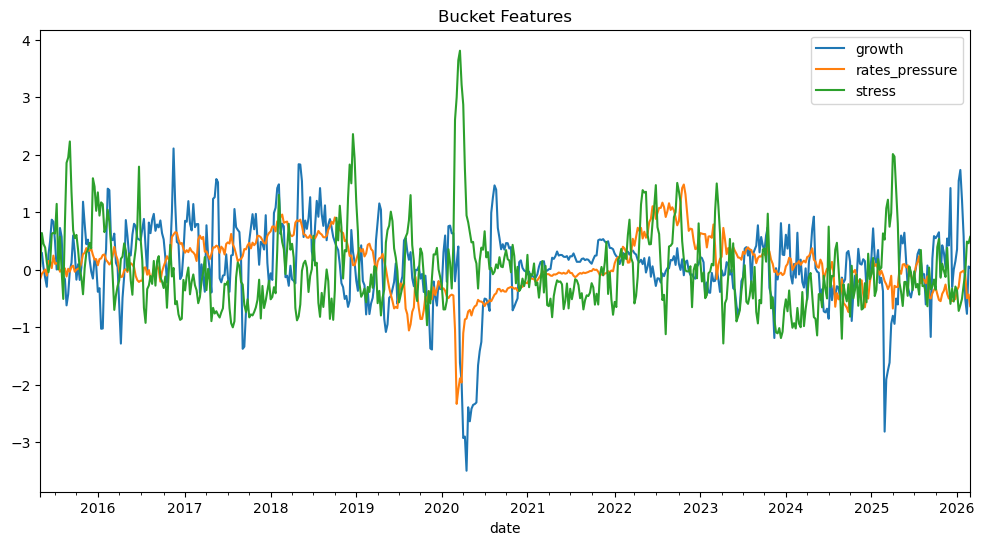

In [10]:
X_model_3.plot(figsize=(12, 6), title="Bucket Features")

## 2.2 Baseline HMM

### Run Benchmark Stack

In [11]:
X_bench = X_model_3.dropna().copy()

gmm_results, gmm_models = data_helpers.fit_gmm_grid(
    X_bench,
    ks=(2, 3, 4),
    n_init=50,
    random_state=42
)

hmm_results, hmm_models = data_helpers.fit_hmm_grid(
    X_bench,
    ks=(2, 3, 4),
    covariance_type="diag",
    seeds=range(30),
    n_iter=2000,
    tol=1e-4
)

print("GMM results")
display(gmm_results)

print("HMM results")
display(hmm_results)

Model is not converging.  Current: -934.424147809941 is not greater than -934.4241439793624. Delta is -3.8305786347336834e-06


GMM results


,model,k,loglik,aic,bic,silhouette
0,GMM,2,-1363.516889,2765.033778,2847.467065,0.428523
1,GMM,3,-1318.075225,2694.150450,2819.969678,0.317073
2,GMM,4,-1300.874204,2679.748409,2848.953578,0.322769


HMM results


,model,k,best_seed,loglik,aic,bic
0,HMM,2,29,-1279.319119,2588.638239,2653.717150
1,HMM,3,5,-1060.757628,2173.515255,2286.318701
2,HMM,4,5,-903.348934,1884.697868,2053.903037


### Diagnostics

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,0.198630,0.043504,-0.252239,0.563332,0.373615,0.402260,439,0.775618,17.560000,10.0,87,25
1,-0.040213,0.472813,0.787062,0.446739,0.445914,0.574611,107,0.189046,4.458333,2.0,17,24
2,-1.778772,-0.947461,1.574675,1.153186,0.629585,1.201654,20,0.035336,5.000000,2.5,14,4


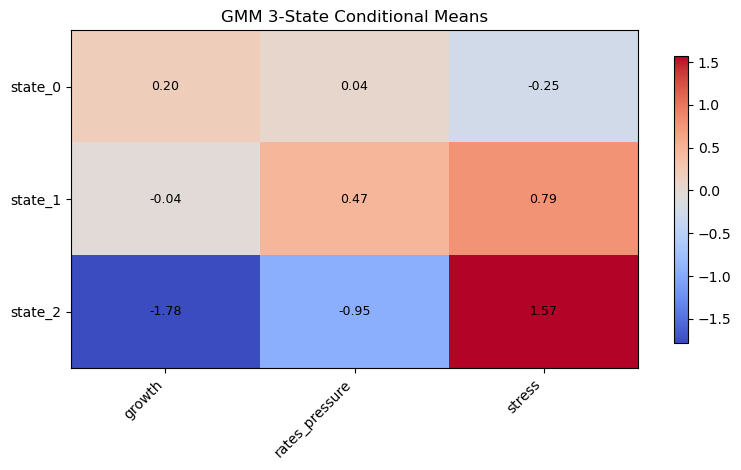

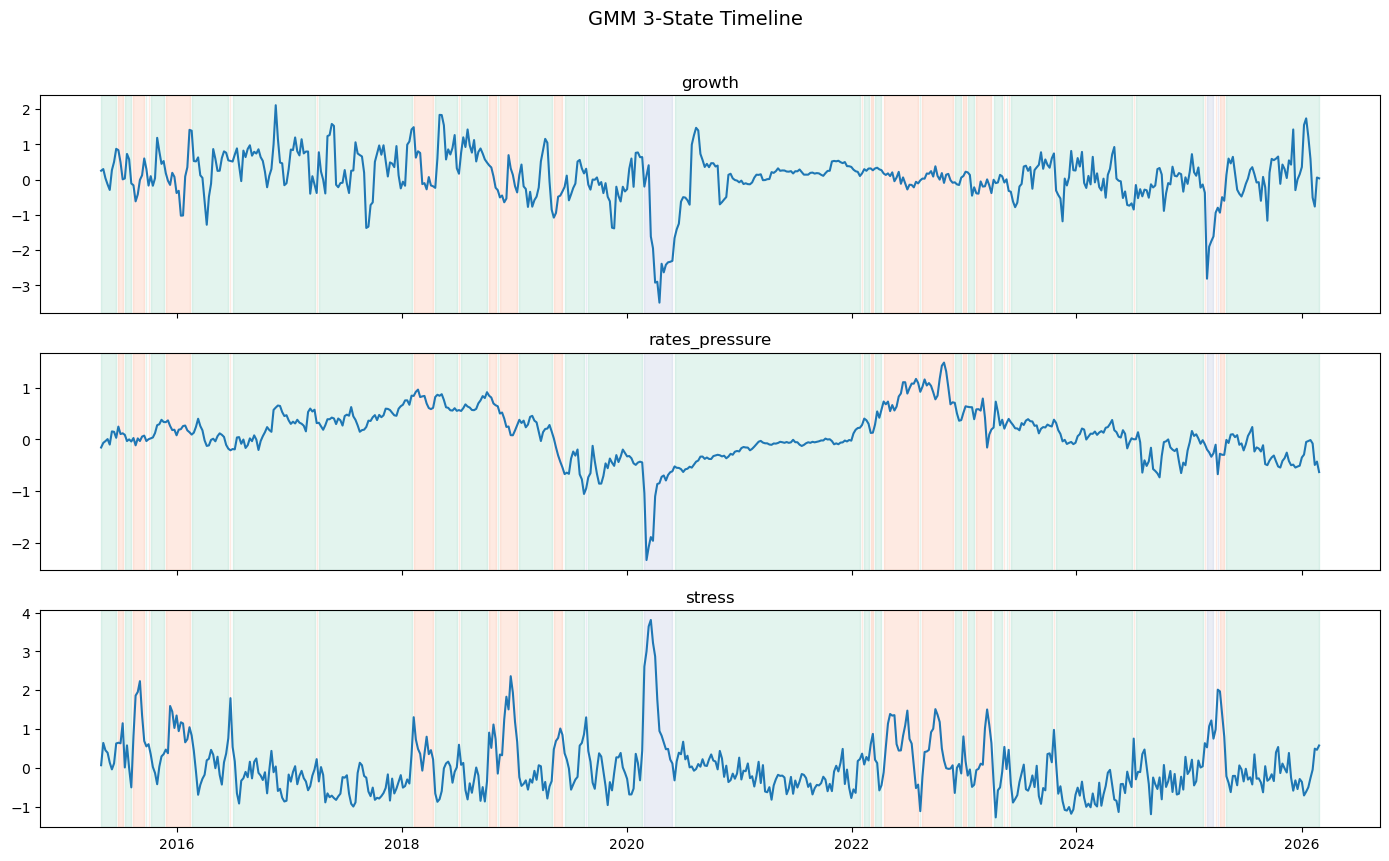

In [12]:
gmm3 = gmm_models[3]

display(gmm3["summary"])
data_helpers.plot_state_means(gmm3["summary"], title="GMM 3-State Conditional Means")
data_helpers.plot_regime_timeline(X_bench, gmm3["labels"], title="GMM 3-State Timeline")

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,0.160656,-0.121392,-0.204311,0.474201,0.218361,0.421254,270,0.477032,24.545455,13.0,77,11
1,0.244233,0.505497,0.031464,0.568109,0.278141,0.676297,238,0.420495,79.333333,93.0,124,3
2,-0.934208,-0.634353,0.907789,1.003740,0.480456,1.040224,58,0.102473,8.285714,8.0,22,7


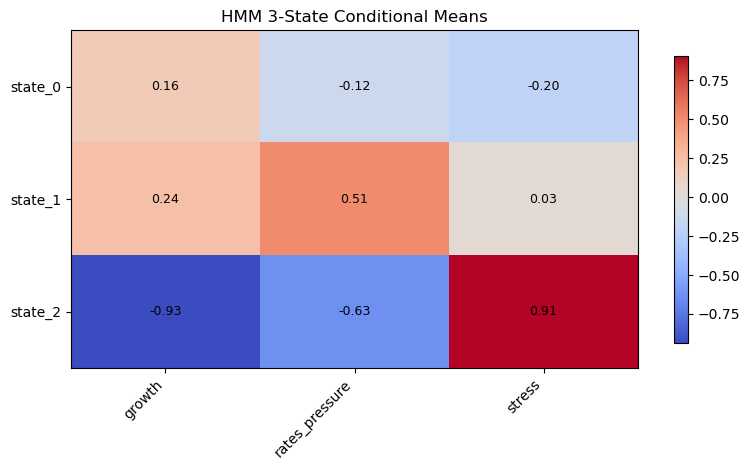

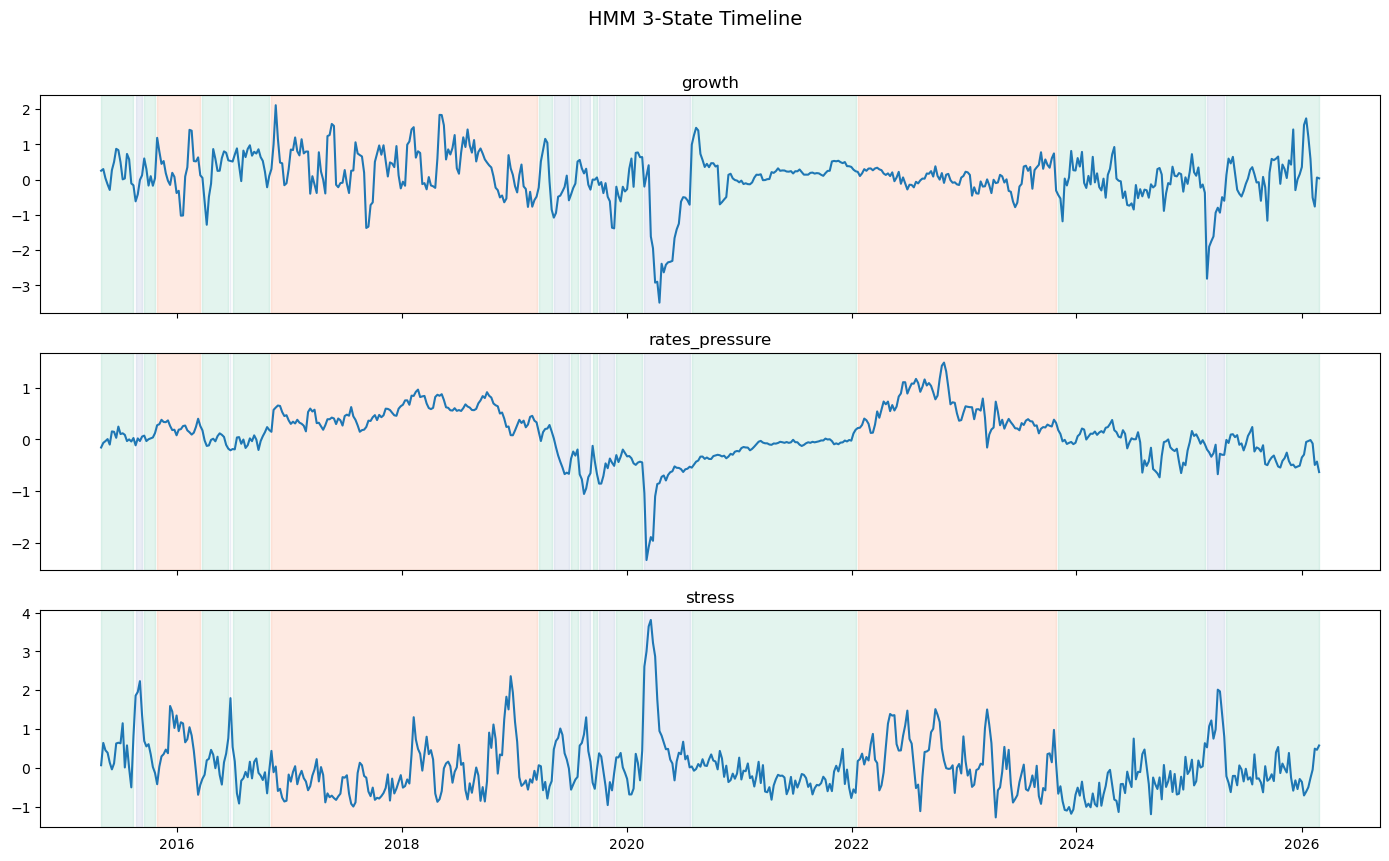

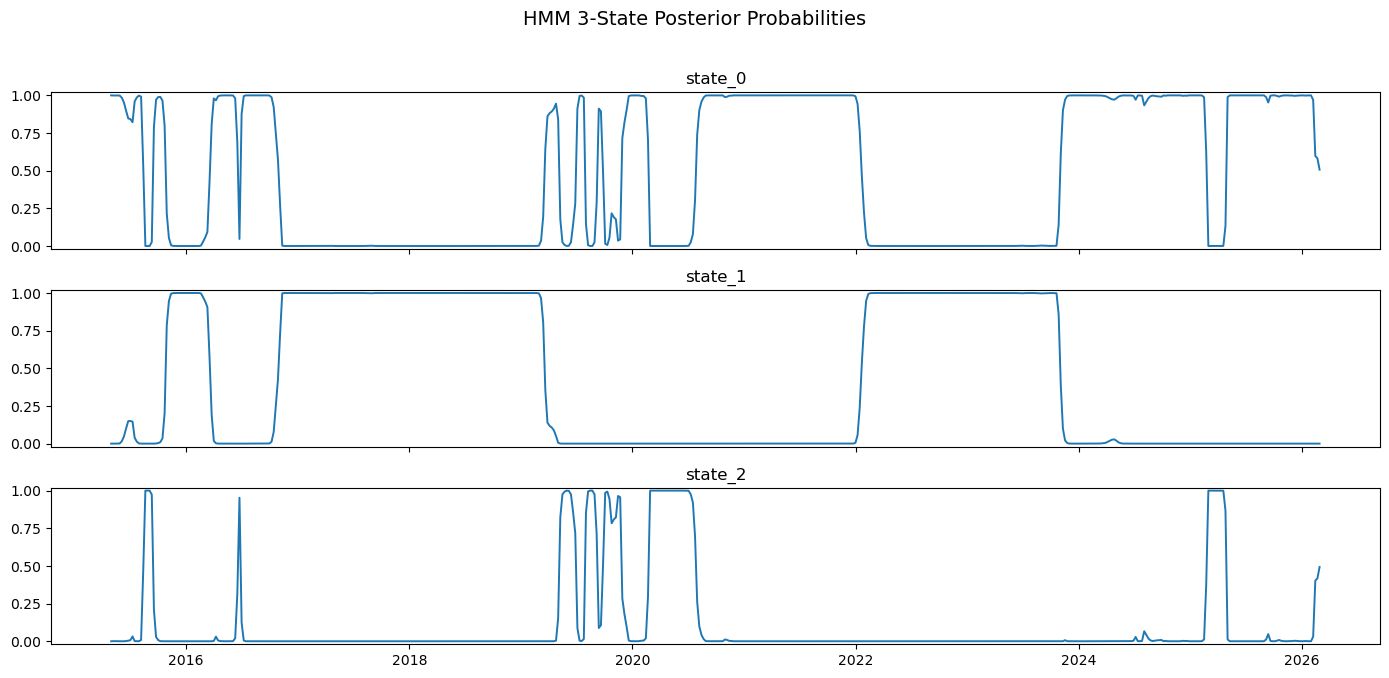

In [13]:
hmm3 = hmm_models[3]

display(hmm3["summary"])
data_helpers.plot_state_means(hmm3["summary"], title="HMM 3-State Conditional Means")
data_helpers.plot_regime_timeline(X_bench, hmm3["labels"], title="HMM 3-State Timeline")
data_helpers.plot_hmm_posteriors(hmm3["probs"], title="HMM 3-State Posterior Probabilities")

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,0.158779,-0.002506,-0.237915,0.456331,0.118031,0.439398,192,0.339223,17.454545,13.0,54,11
1,-0.020632,-0.445500,-0.028732,0.607518,0.153478,0.416529,107,0.189046,15.285714,13.0,31,7
2,0.244000,0.507016,0.029767,0.569300,0.277739,0.677220,237,0.418728,79.000000,93.0,123,3
3,-1.292852,-0.709101,1.555850,1.198682,0.639056,1.014129,30,0.053004,6.000000,4.0,14,5


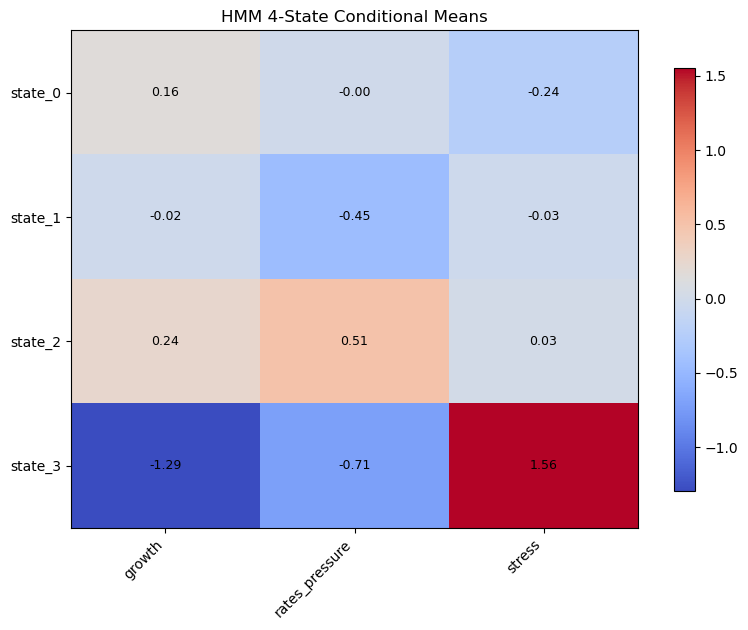

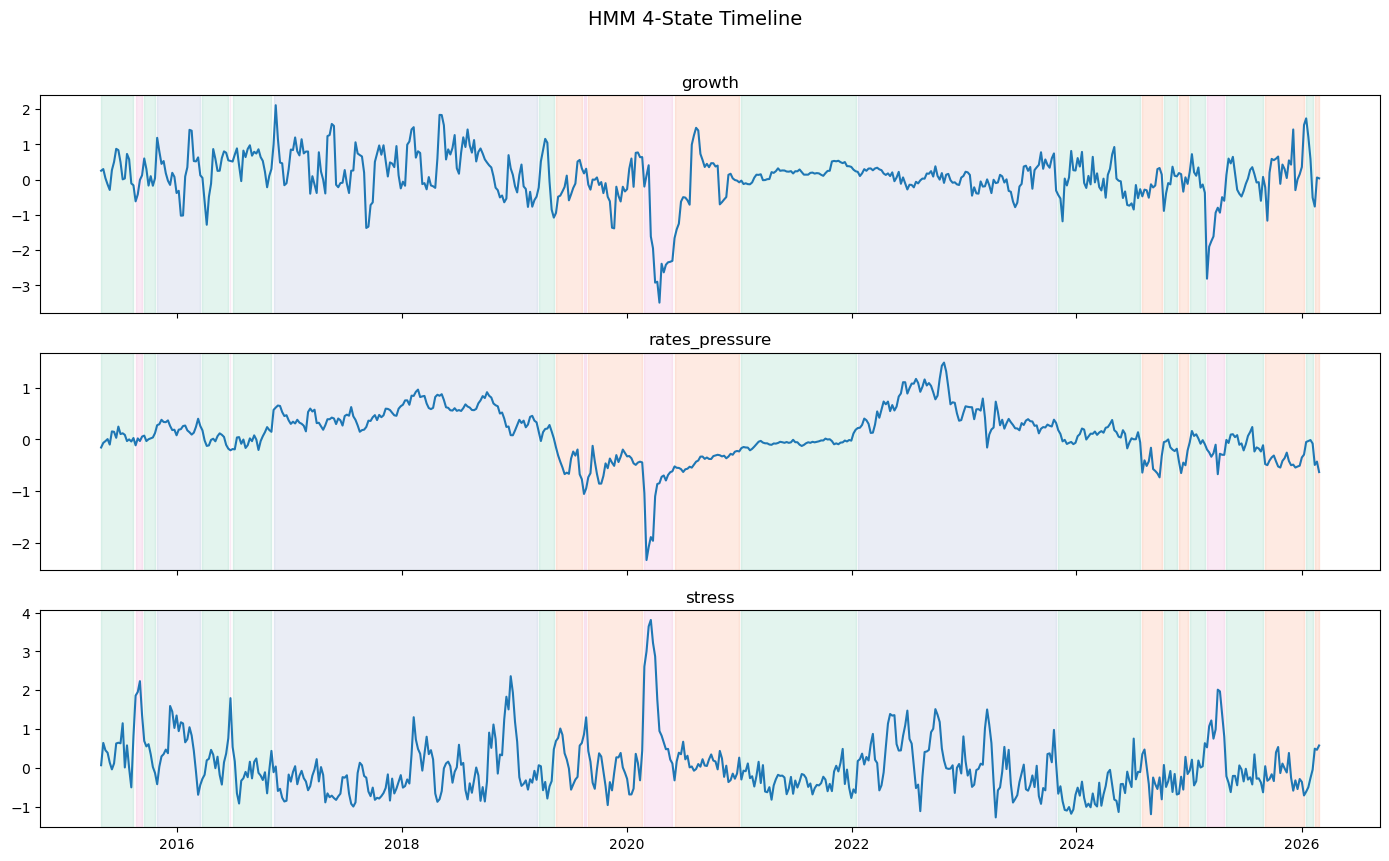

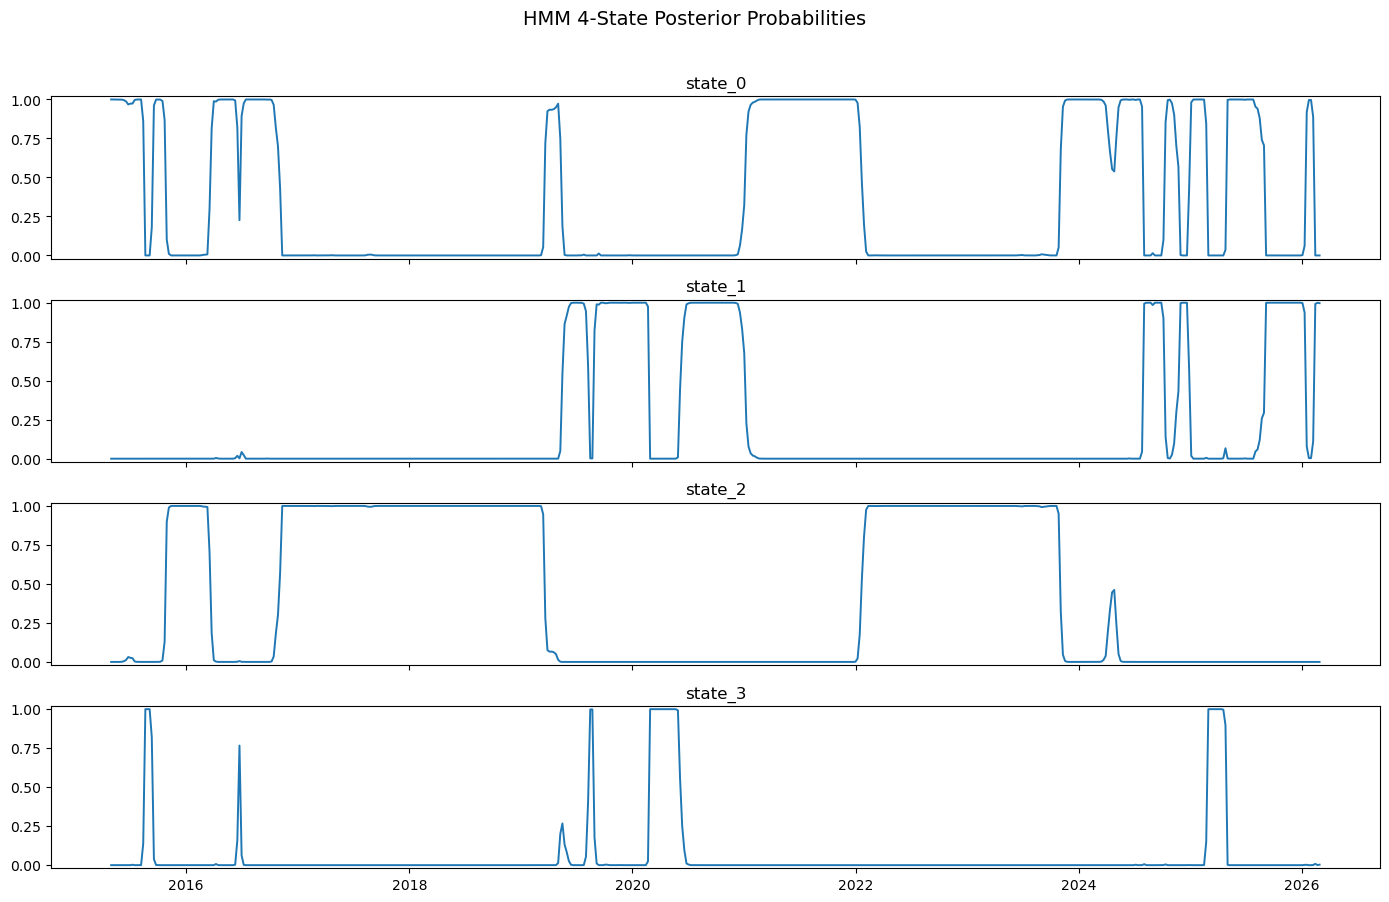

In [14]:
hmm4 = hmm_models[4]

display(hmm4["summary"])
data_helpers.plot_state_means(hmm4["summary"], title="HMM 4-State Conditional Means")
data_helpers.plot_regime_timeline(X_bench, hmm4["labels"], title="HMM 4-State Timeline")
data_helpers.plot_hmm_posteriors(hmm4["probs"], title="HMM 4-State Posterior Probabilities")

In [15]:
print("GMM 3-state")
display(data_helpers.compact_regime_report(gmm_models[3]["summary"]))

print("HMM 3-state")
display(data_helpers.compact_regime_report(hmm_models[3]["summary"]))

print("HMM 4-state")
display(data_helpers.compact_regime_report(hmm_models[4]["summary"]))

GMM 3-state


,growth_mean,rates_pressure_mean,stress_mean,occupancy,avg_duration,median_duration,n_runs
state,,,,,,,
0,0.198630,0.043504,-0.252239,0.775618,17.560000,10.0,25
1,-0.040213,0.472813,0.787062,0.189046,4.458333,2.0,24
2,-1.778772,-0.947461,1.574675,0.035336,5.000000,2.5,4


HMM 3-state


,growth_mean,rates_pressure_mean,stress_mean,occupancy,avg_duration,median_duration,n_runs
state,,,,,,,
0,0.160656,-0.121392,-0.204311,0.477032,24.545455,13.0,11
1,0.244233,0.505497,0.031464,0.420495,79.333333,93.0,3
2,-0.934208,-0.634353,0.907789,0.102473,8.285714,8.0,7


HMM 4-state


,growth_mean,rates_pressure_mean,stress_mean,occupancy,avg_duration,median_duration,n_runs
state,,,,,,,
0,0.158779,-0.002506,-0.237915,0.339223,17.454545,13.0,11
1,-0.020632,-0.445500,-0.028732,0.189046,15.285714,13.0,7
2,0.244000,0.507016,0.029767,0.418728,79.000000,93.0,3
3,-1.292852,-0.709101,1.555850,0.053004,6.000000,4.0,5


,state_0,state_1,state_2
state_0,0.957734,1.214040e-02,3.012515e-02
state_1,0.013432,9.865682e-01,1.138445e-17
state_2,0.123304,9.737198e-21,8.766956e-01


state_0    23.659929
state_1    74.450408
state_2     8.110014
Name: implied_duration, dtype: float64

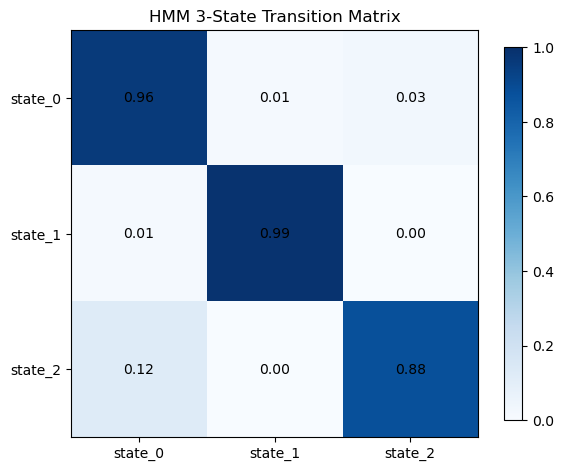

In [16]:
hmm3 = hmm_models[3]

if "mapping" not in hmm3:
    raw_labels = hmm3["model"].predict(X_bench.values)
    relabeled, mapping, means = data_helpers.relabel_states_by_macro_order(X_bench, raw_labels)
    hmm3["mapping"] = mapping
    hmm3["means"] = means

T3, order3 = data_helpers.reorder_transition_matrix(hmm3)
display(T3)

dur3 = data_helpers.implied_state_durations(T3)
display(dur3)

data_helpers.plot_transition_matrix(T3, title="HMM 3-State Transition Matrix")

In [17]:
regime_panel_full = data_helpers.make_regime_panel(X_bench, hmm3)
display(regime_panel_full.head())
display(regime_panel_full.tail())

,growth,rates_pressure,stress,state,p_state_0,p_state_1,p_state_2
date,,,,,,,
2015-05-01,0.250357,-0.157632,0.064364,0,1.000000,1.844364e-46,6.294102e-48
2015-05-08,0.297021,-0.068270,0.639529,0,0.999001,7.777622e-05,9.207999e-04
2015-05-15,0.039502,-0.034480,0.449829,0,0.999340,1.102730e-04,5.501462e-04
2015-05-22,-0.138421,0.004524,0.387080,0,0.999176,3.117478e-04,5.124875e-04
2015-05-29,-0.294907,-0.101015,0.133351,0,0.998559,1.116903e-03,3.245694e-04


,growth,rates_pressure,stress,state,p_state_0,p_state_1,p_state_2
date,,,,,,,
2026-01-30,0.581064,-0.013692,-0.266149,0,0.999569,0.000021,0.000410
2026-02-06,-0.513366,-0.080765,-0.049563,0,0.969772,0.000007,0.030222
2026-02-13,-0.765823,-0.494528,0.491179,0,0.597745,0.000001,0.402254
2026-02-20,0.057639,-0.429597,0.462238,0,0.581561,0.000002,0.418437
2026-02-27,0.034139,-0.632517,0.573092,0,0.506908,0.000043,0.493049


## 2.3 Realtime Evaluation

In [18]:
probs_oos_3, meta_oos_3, fitted_oos_3 = data_helpers.expanding_filtered_hmm(
    X=X_model_3,
    k=3,
    min_train=156,
    refit_every=1,          # change to 4 if this is slow
    covariance_type="diag",
    seeds=range(10),
    n_iter=1000,
    tol=1e-4,
)

display(probs_oos_3.head())
display(probs_oos_3.tail())

Model is not converging.  Current: -208.52630322387287 is not greater than -208.5258844504899. Delta is -0.00041877338296103517
Model is not converging.  Current: -171.5846595183084 is not greater than -171.5843968878086. Delta is -0.00026263049980457254
Model is not converging.  Current: -172.08314754166813 is not greater than -172.08287372543768. Delta is -0.00027381623044675507
Model is not converging.  Current: -172.45595216487604 is not greater than -172.45562416609872. Delta is -0.0003279987773225912
Model is not converging.  Current: -175.49558448268587 is not greater than -175.49551072043576. Delta is -7.376225011057613e-05
Model is not converging.  Current: -195.3750479143494 is not greater than -195.37466933515876. Delta is -0.00037857919065231727
Model is not converging.  Current: -221.47942833857567 is not greater than -221.47928779478465. Delta is -0.0001405437910193541
Model is not converging.  Current: -175.92881149772026 is not greater than -175.92875716549682. Delta is

,p_state_0,p_state_1,p_state_2,state
2018-04-20,1.156605e-03,0.998843,7.147095e-31,1
2018-04-27,3.340616e-43,1.000000,3.371244e-54,1
2018-05-04,1.640059e-16,1.000000,4.928604e-30,1
2018-05-11,5.078050e-42,1.000000,5.045172e-56,1
2018-05-18,1.566855e-04,0.999843,9.726240e-34,1


,p_state_0,p_state_1,p_state_2,state
2026-01-30,0.998151,0.001479,0.000370,0
2026-02-06,0.996655,0.000799,0.002546,0
2026-02-13,0.758292,0.000144,0.241563,0
2026-02-20,0.873001,0.000133,0.126866,0
2026-02-27,0.506908,0.000043,0.493049,0


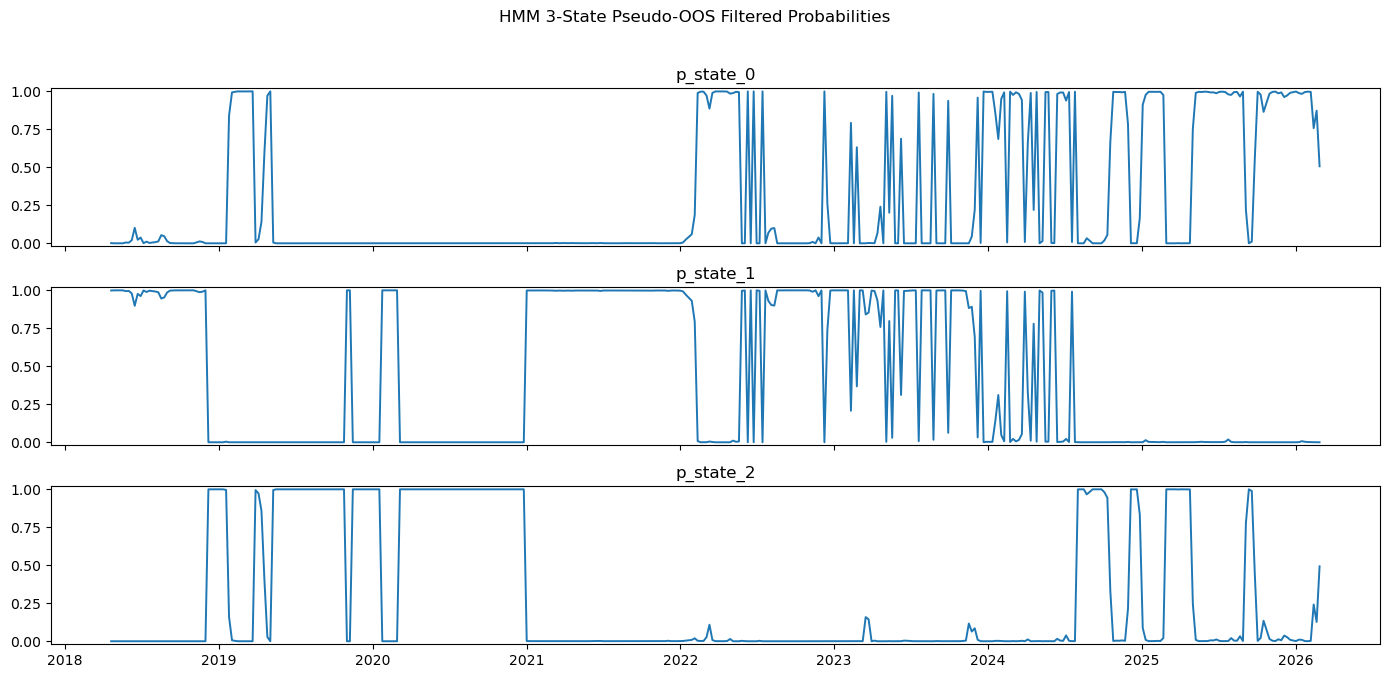

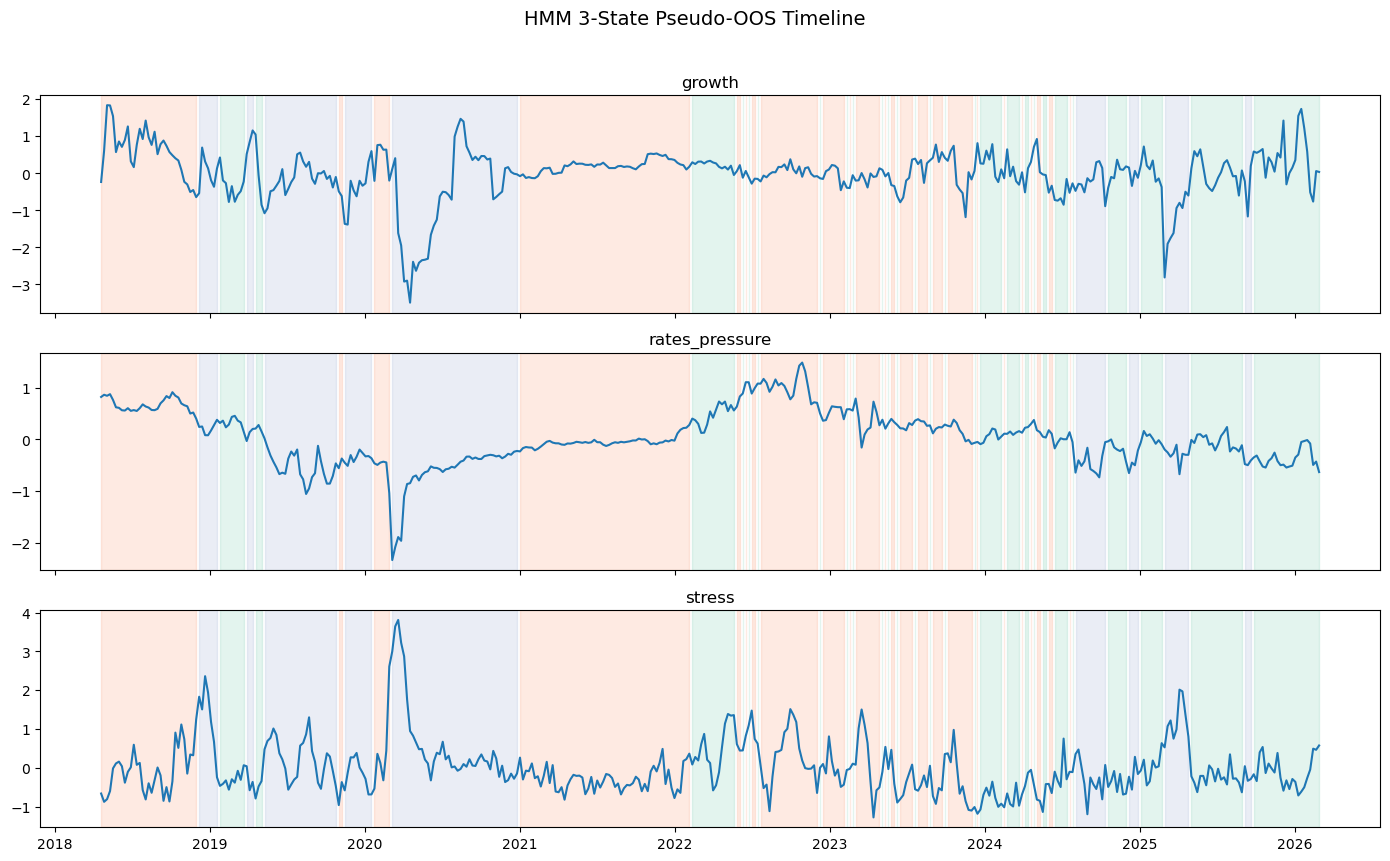

In [19]:
data_helpers.plot_oos_state_probs(probs_oos_3, title="HMM 3-State Pseudo-OOS Filtered Probabilities")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_3, title="HMM 3-State Pseudo-OOS Timeline")

In [20]:
compare_states = pd.DataFrame({
    "full_sample_state": hmm3["labels"].reindex(probs_oos_3.index),
    "oos_filtered_state": probs_oos_3["state"]
}).dropna()

compare_states["match"] = (
    compare_states["full_sample_state"].astype(int) ==
    compare_states["oos_filtered_state"].astype(int)
)

match_rate = compare_states["match"].mean()
print("State match rate:", round(match_rate, 4))

display(pd.crosstab(
    compare_states["full_sample_state"],
    compare_states["oos_filtered_state"],
    normalize="index"
))

State match rate: 0.5693


oos_filtered_state,0,1,2
full_sample_state,,,
0,0.391705,0.341014,0.267281
1,0.248227,0.702128,0.049645
2,0.000000,0.056604,0.943396


In [21]:
oos_state_summary = data_helpers.summarize_state_sequence(probs_oos_3["state"])
display(oos_state_summary)

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,120,0.291971,4.444444,1.0,23,27
1,176,0.428224,7.333333,2.0,58,24
2,115,0.279805,12.777778,9.0,43,9


In [22]:
switches_oos_3 = data_helpers.regime_switch_table(probs_oos_3["state"])
display(switches_oos_3.head(20))

,date,state,prev_state,switch
0,2018-04-20,1,NaN,True
1,2018-12-07,2,1.0,True
2,2019-01-25,0,2.0,True
3,2019-03-29,2,0.0,True
4,2019-04-19,0,2.0,True
5,2019-05-10,2,0.0,True
6,2019-11-01,1,2.0,True
7,2019-11-15,2,1.0,True
8,2020-01-24,1,2.0,True
9,2020-03-06,2,1.0,True


### 2 State Trial

Model is not converging.  Current: -211.57279522952774 is not greater than -211.57278106055315. Delta is -1.4168974587391858e-05
Model is not converging.  Current: -211.5728106045556 is not greater than -211.5727633377595. Delta is -4.726679608779705e-05
Model is not converging.  Current: -211.57288534598092 is not greater than -211.57273739665857. Delta is -0.00014794932235417946
Model is not converging.  Current: -214.39018903554572 is not greater than -214.3901746669055. Delta is -1.4368640222528484e-05
Model is not converging.  Current: -214.3901930351163 is not greater than -214.39017094494253. Delta is -2.2090173786182277e-05
Model is not converging.  Current: -214.39024946582174 is not greater than -214.39014868752093. Delta is -0.00010077830080490457
Model is not converging.  Current: -214.41099557639535 is not greater than -214.41092711119035. Delta is -6.84652050040313e-05
Model is not converging.  Current: -241.3156860939611 is not greater than -241.31567021563728. Delta is 

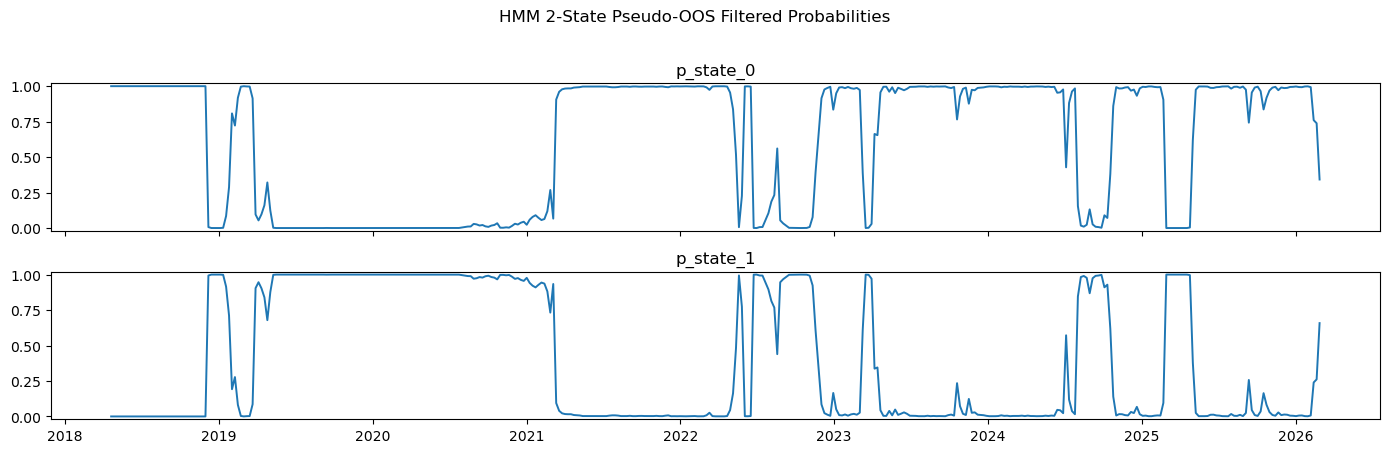

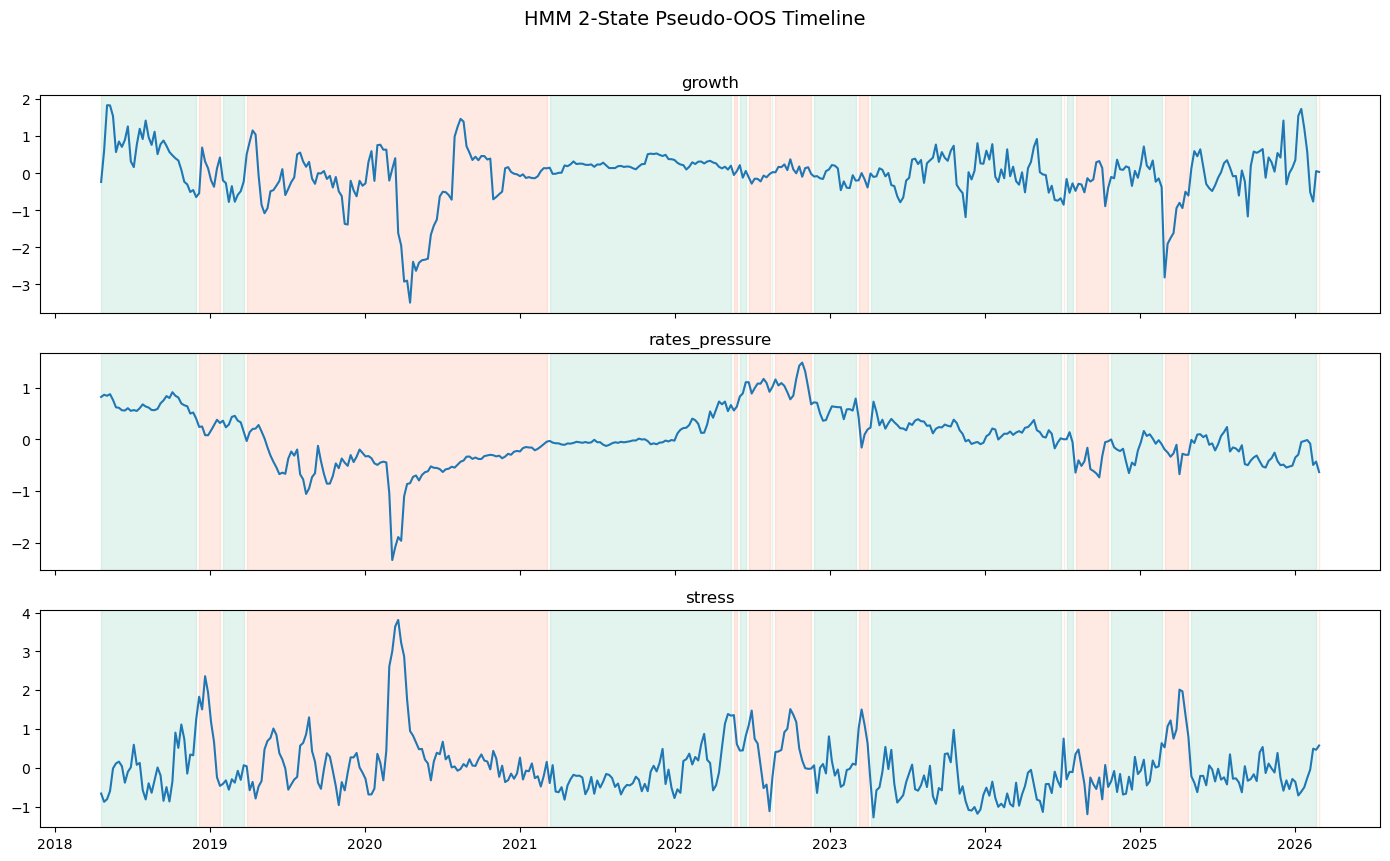

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,251,0.610706,25.1,16.5,65,10
1,160,0.389294,16.0,8.0,102,10


In [23]:
probs_oos_2, meta_oos_2, fitted_oos_2 = data_helpers.expanding_filtered_hmm(
    X=X_model_3,
    k=2,
    min_train=156,
    refit_every=1,
    covariance_type="diag",
    seeds=range(10),
    n_iter=1000,
    tol=1e-4,
)

data_helpers.plot_oos_state_probs(probs_oos_2, title="HMM 2-State Pseudo-OOS Filtered Probabilities")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_2, title="HMM 2-State Pseudo-OOS Timeline")
display(data_helpers.summarize_state_sequence(probs_oos_2["state"]))

## 3 States slower refit trial

Model is not converging.  Current: -172.08314754166813 is not greater than -172.08287372543768. Delta is -0.00027381623044675507
Model is not converging.  Current: -222.08273871730745 is not greater than -222.0826563934141. Delta is -8.23238933378434e-05
Model is not converging.  Current: -174.56913754315707 is not greater than -174.568832269119. Delta is -0.0003052740380553587
Model is not converging.  Current: -177.5815937196147 is not greater than -177.58151364575525. Delta is -8.007385943642475e-05
Model is not converging.  Current: -225.6178182511683 is not greater than -225.61774122424106. Delta is -7.702692724365079e-05
Model is not converging.  Current: -177.68301230422122 is not greater than -177.68245408140112. Delta is -0.0005582228201035377
Model is not converging.  Current: -180.6288447783682 is not greater than -180.6285686051266. Delta is -0.0002761732416161067
Model is not converging.  Current: -180.62876447776284 is not greater than -180.62856829451175. Delta is -0.000

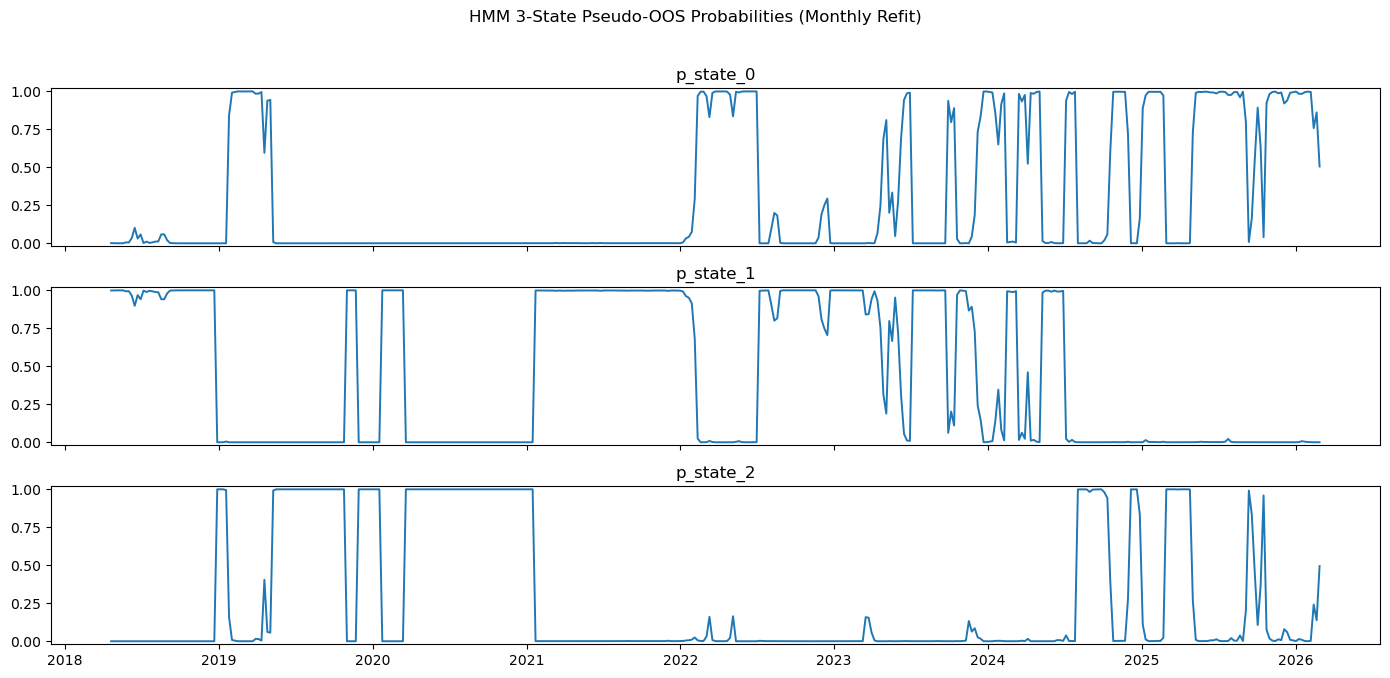

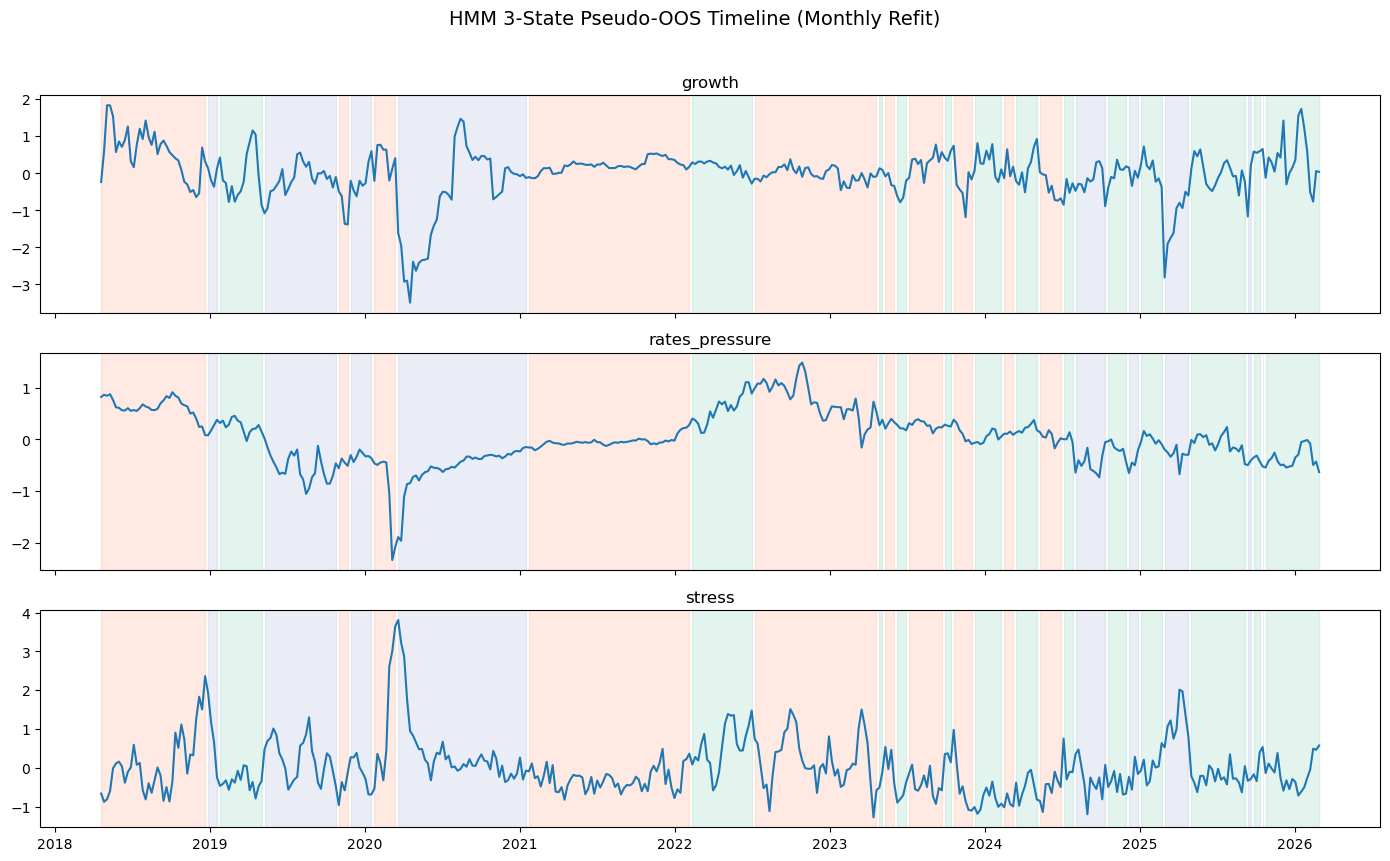

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,123,0.299270,9.461538,8.0,21,13
1,180,0.437956,18.000000,8.0,55,10
2,108,0.262774,12.000000,8.0,44,9


In [24]:
probs_oos_3_m, meta_oos_3_m, fitted_oos_3_m = data_helpers.expanding_filtered_hmm(
    X=X_model_3,
    k=3,
    min_train=156,
    refit_every=4,   # refit every 4 weeks
    covariance_type="diag",
    seeds=range(10),
    n_iter=1000,
    tol=1e-4,
)

data_helpers.plot_oos_state_probs(probs_oos_3_m, title="HMM 3-State Pseudo-OOS Probabilities (Monthly Refit)")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_3_m, title="HMM 3-State Pseudo-OOS Timeline (Monthly Refit)")
display(data_helpers.summarize_state_sequence(probs_oos_3_m["state"]))

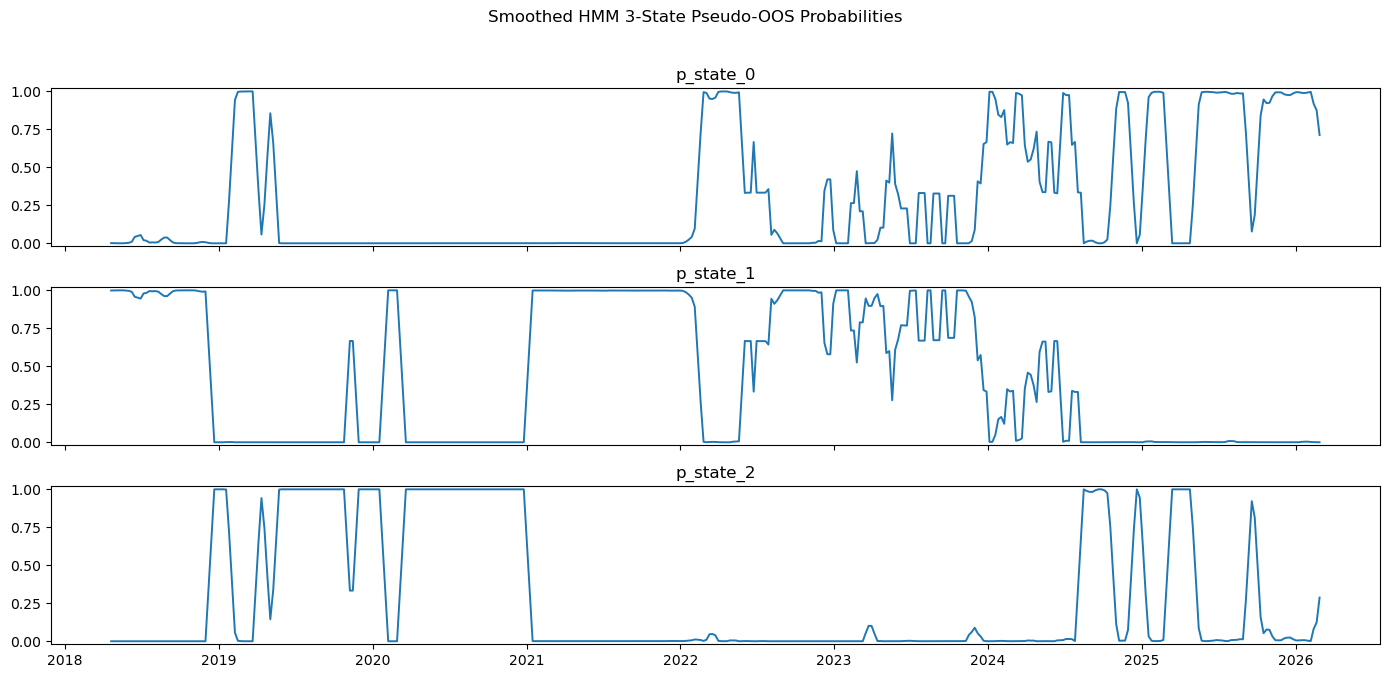

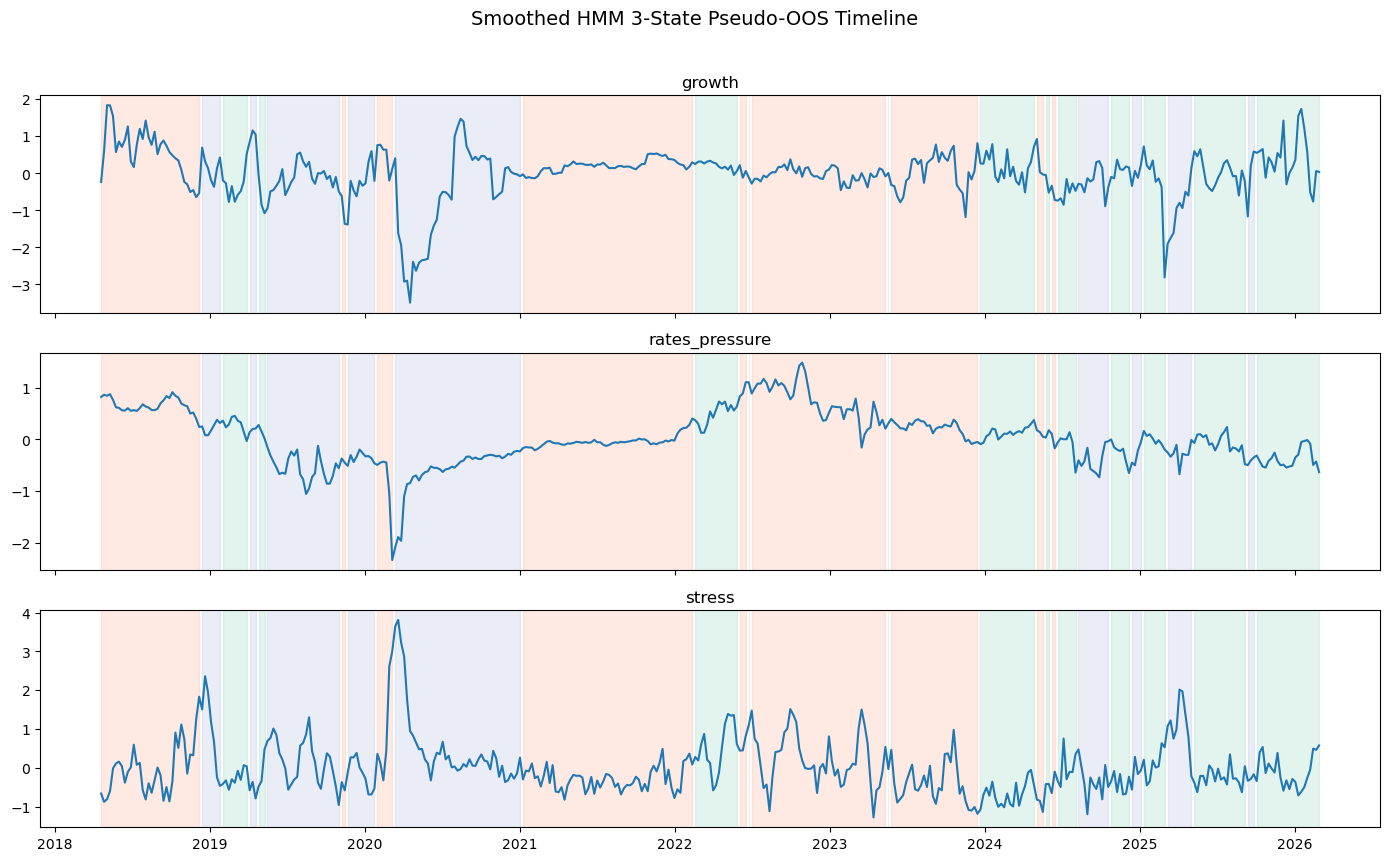

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,112,0.272506,9.333333,7.5,22,12
1,184,0.447689,20.444444,6.0,58,9
2,115,0.279805,12.777778,9.0,43,9


In [25]:
probs_oos_3_s = data_helpers.smooth_state_probs(probs_oos_3, window=3)

data_helpers.plot_oos_state_probs(probs_oos_3_s, title="Smoothed HMM 3-State Pseudo-OOS Probabilities")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_3_s, title="Smoothed HMM 3-State Pseudo-OOS Timeline")
display(data_helpers.summarize_state_sequence(probs_oos_3_s["state"]))

,p_stress,stress_flag_50,stress_flag_70
2026-01-30,0.000370,0,0
2026-02-06,0.002546,0,0
2026-02-13,0.241563,0,0
2026-02-20,0.126866,0,0
2026-02-27,0.493049,0,0


<Axes: title={'center': 'Pseudo-OOS Stress Probability'}>

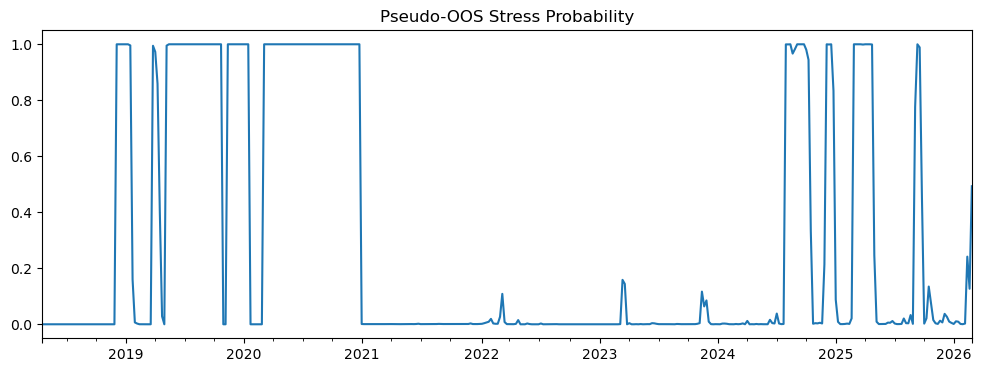

In [26]:
stress_monitor = pd.DataFrame(index=probs_oos_3.index)
stress_monitor["p_stress"] = probs_oos_3["p_state_2"]   # assuming state_2 is the stress state
stress_monitor["stress_flag_50"] = (stress_monitor["p_stress"] > 0.50).astype(int)
stress_monitor["stress_flag_70"] = (stress_monitor["p_stress"] > 0.70).astype(int)

display(stress_monitor.tail())
stress_monitor["p_stress"].plot(figsize=(12, 4), title="Pseudo-OOS Stress Probability")

## 2.4 Asset Behavior Interpretation

### ETF (Equities Returns)

In [27]:
tickers_set = ["SPY", "IEF", "TLT", "LQD", "HYG", "TIP"]
etf_path_dir = Path.home() / 'Desktop' / 'Data' / 'ETF' / 'ETF'
etf_prices = data_helpers.load_prices(folder=etf_path_dir,tickers_set=tickers_set)

In [28]:
etf_prices_weekly = data_helpers.daily_to_weekly(etf_prices,research_index=X_model_3.index,freq="W-FRI")
etf_returns_weekly = etf_prices_weekly.pct_change()

In [29]:
etf_returns_weekly

,HYG,IEF,LQD,SPY,TIP,TLT
date,,,,,,
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN
2015-05-08,0.003194,-0.000562,0.000504,0.004271,-0.005619,-0.012016
2015-05-15,-0.000769,0.000094,-0.002185,0.003875,-0.000883,-0.007510
2015-05-22,-0.002198,-0.005341,-0.007747,0.002589,-0.001944,-0.009787
2015-05-29,0.001101,0.007159,0.003734,-0.008686,0.002479,0.019186
...,...,...,...,...,...,...
2026-01-30,-0.000246,-0.000104,-0.002436,0.003975,0.002268,-0.009098
2026-02-06,-0.003821,0.001355,-0.000090,-0.001951,0.001720,0.004706
2026-02-13,0.000495,0.011866,0.009316,-0.012844,0.006506,0.024903


### Cash/Rates

In [30]:
os.environ["FRED_API_KEY"] = "656d2723f313fd2fe2e6fceb0b265613"

In [31]:
yield_series_map={
    "cash_yield_3m": "TB3MS",   # 3M T-bill yield (%)
    "fedfunds": "DFF",          # Effective fed funds (%)
    "ust_2y": "DGS2",           # 2Y Treasury yield (%)
    "ust_10y": "DGS10",         # 10Y Treasury yield (%)
}

In [32]:
def get_series_vintage_dates(series_id, api_key,
                             realtime_start=None, realtime_end=None):
    url = "https://api.stlouisfed.org/fred/series/vintagedates"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "limit": 10000,
    }
    if realtime_start is not None:
        params["realtime_start"] = realtime_start
    if realtime_end is not None:
        params["realtime_end"] = realtime_end

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()
    return pd.to_datetime(js["vintage_dates"])

def get_alfred_series_asof(series_id, vintage_date, api_key,
                           observation_start=None, observation_end=None):
    """
    Pull one ALFRED/FRED series as known on `vintage_date`
    using the observations endpoint + vintage_dates parameter.
    """
    url = "https://api.stlouisfed.org/fred/series/observations"

    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "vintage_dates": vintage_date,   # key fix
    }

    if observation_start is not None:
        params["observation_start"] = observation_start
    if observation_end is not None:
        params["observation_end"] = observation_end

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    s = df.set_index("date")["value"].sort_index()
    s.name = series_id
    return s 

def load_series_asof(vintage_date, api_key,
                      observation_start=None, observation_end=None,
                      series_map=None):
    series_map = yield_series_map if series_map is None else series_map

    out = {}
    for name, sid in series_map.items():
        out[name] = get_alfred_series_asof(
            series_id=sid,
            vintage_date=vintage_date,
            api_key=api_key,
            observation_start=observation_start,
            observation_end=observation_end,
        )

    df = pd.concat(out, axis=1).sort_index()
    return df

def annual_yield_to_weekly_return(yield_series_pct, periods_per_year=52):
    """
    Convert annualized yield in percent to weekly simple return.
    """
    y = pd.to_numeric(yield_series_pct, errors="coerce") / 100.0
    return (1.0 + y) ** (1.0 / periods_per_year) - 1.0

In [33]:
series_df = load_series_asof(
    vintage_date="2026-03-07",
    api_key=os.environ['FRED_API_KEY'],
    observation_start="2014-01-01",
)

In [34]:
s_weekly = series_df.resample('W-FRI').last().ffill()
s_weekly = s_weekly.reindex(X_model_3.index).ffill()

In [35]:
s_weekly.head()

,cash_yield_3m,fedfunds,ust_2y,ust_10y
date,,,,
2015-05-01,0.02,0.13,0.60,2.12
2015-05-08,0.02,0.13,0.59,2.16
2015-05-15,0.02,0.13,0.55,2.14
2015-05-22,0.02,0.13,0.64,2.21
2015-05-29,0.02,0.08,0.61,2.12


In [36]:
rates_returns = pd.DataFrame(index=s_weekly.index)
rates_returns["cash_ret"] = annual_yield_to_weekly_return(s_weekly["cash_yield_3m"])
# Optional rate-change features if useful later
rates_features = pd.DataFrame(index=s_weekly.index)
rates_features["fedfunds"] = s_weekly["fedfunds"]
rates_features["ust_2y"] = s_weekly["ust_2y"]
rates_features["ust_10y"] = s_weekly["ust_10y"]
rates_features["curve_10y_2y"] = s_weekly["ust_10y"] - s_weekly["ust_2y"]
rates_features["d_2y"] = s_weekly["ust_2y"].diff()
rates_features["d_10y"] = s_weekly["ust_10y"].diff()

In [37]:
asset_returns = etf_returns_weekly.join(rates_returns[["cash_ret"]], how="left")

In [38]:
asset_returns.tail()

,HYG,IEF,LQD,SPY,TIP,TLT,cash_ret
date,,,,,,,
2026-01-30,-0.000246,-0.000104,-0.002436,0.003975,0.002268,-0.009098,0.000675
2026-02-06,-0.003821,0.001355,-0.000090,-0.001951,0.001720,0.004706,0.000680
2026-02-13,0.000495,0.011866,0.009316,-0.012844,0.006506,0.024903,0.000680
2026-02-20,0.001855,-0.001234,0.000000,0.011265,-0.001795,-0.003455,0.000680
2026-02-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000680


In [39]:
def align_asset_returns(asset_returns, regime_index):
    """
    Align asset return panel to a regime index.
    """
    idx = pd.DatetimeIndex(regime_index).sort_values()
    out = asset_returns.copy().sort_index()
    out = out.reindex(idx)
    return out

In [40]:
asset_returns_2s = align_asset_returns(asset_returns, probs_oos_2.index)
asset_returns_3s = align_asset_returns(asset_returns, probs_oos_3_m.index)

In [41]:
results_2s = data_helpers.regime_forward_return_stats(
    state_series=probs_oos_2["state"],
    asset_returns=asset_returns_2s,
    horizons=(1, 4, 12),
)

In [42]:
results_3s = data_helpers.regime_forward_return_stats(
    state_series=probs_oos_3_m["state"],   # or probs_oos_3_s["state"]
    asset_returns=asset_returns_3s,
    horizons=(1, 4, 12),
)

In [43]:
mean_4w_2s = data_helpers.regime_mean_table(results_2s, horizon=4)
hit_4w_2s = data_helpers.regime_hit_rate_table(results_2s, horizon=4)

display(mean_4w_2s)
display(hit_4w_2s)

state,0,1
asset,,
HYG,-0.001846,0.002173
IEF,-0.001296,0.001204
LQD,-0.002065,0.003253
SPY,0.008093,0.014394
TIP,-0.001221,0.001884
TLT,-0.003531,0.000138
cash_ret,0.002329,0.001441


state,0,1
asset,,
HYG,0.489960,0.616352
IEF,0.522088,0.522013
LQD,0.510040,0.591195
SPY,0.666667,0.679245
TIP,0.485944,0.622642
TLT,0.493976,0.471698
cash_ret,1.000000,1.000000


In [44]:
mean_4w_3s = data_helpers.regime_mean_table(results_3s, horizon=4)
hit_4w_3s = data_helpers.regime_hit_rate_table(results_3s, horizon=4)

display(mean_4w_3s)
display(hit_4w_3s)

state,0,1,2
asset,,,
HYG,-0.001329,-0.004368,0.007699
IEF,-0.001289,-0.000078,0.000346
LQD,-0.001653,-0.003467,0.007644
SPY,0.008714,0.003090,0.025019
TIP,-0.000735,-0.001942,0.004010
TLT,-0.005406,0.000325,-0.002472
cash_ret,0.002720,0.001862,0.001366


state,0,1,2
asset,,,
HYG,0.566667,0.472222,0.620370
IEF,0.533333,0.533333,0.490741
LQD,0.575000,0.488889,0.592593
SPY,0.700000,0.627778,0.712963
TIP,0.550000,0.488889,0.611111
TLT,0.475000,0.516667,0.444444
cash_ret,1.000000,1.000000,1.000000


In [45]:
pw_results_3s = data_helpers.probability_weighted_forward_returns(
    probs_df=probs_oos_3_m,   # or smoothed version
    asset_returns=asset_returns_3s,
    horizons=(1, 4, 12),
)

display(pw_results_3s["SPY"][4])
display(pw_results_3s["IEF"][4])
display(pw_results_3s["TLT"][4])

,prob_weighted_mean,avg_probability,n_obs
p_state_0,0.008097,0.287345,408.0
p_state_1,0.003153,0.437696,408.0
p_state_2,0.024883,0.274959,408.0


,prob_weighted_mean,avg_probability,n_obs
p_state_0,-0.001263,0.287345,408.0
p_state_1,-0.000160,0.437696,408.0
p_state_2,0.000404,0.274959,408.0


,prob_weighted_mean,avg_probability,n_obs
p_state_0,-0.005493,0.287345,408.0
p_state_1,0.000160,0.437696,408.0
p_state_2,-0.002154,0.274959,408.0


In [46]:
asset_returns_2s["TLT_minus_SPY"] = asset_returns_2s["TLT"] - asset_returns_2s["SPY"]
asset_returns_2s["IEF_minus_SPY"] = asset_returns_2s["IEF"] - asset_returns_2s["SPY"]
asset_returns_2s["LQD_minus_IEF"] = asset_returns_2s["LQD"] - asset_returns_2s["IEF"]
asset_returns_2s["HYG_minus_LQD"] = asset_returns_2s["HYG"] - asset_returns_2s["LQD"]

In [47]:
def display_regime_stats(results, asset_list=None):
    """
    Pretty display helper.
    """
    assets = list(results.keys()) if asset_list is None else asset_list

    for asset in assets:
        print(f"\n========== {asset} ==========")
        for h, df in results[asset].items():
            print(f"\nForward horizon: {h} weeks")
            display(df)

In [48]:
spread_results_2s = data_helpers.regime_forward_return_stats(
    state_series=probs_oos_2["state"],
    asset_returns=asset_returns_2s[["TLT_minus_SPY", "IEF_minus_SPY", "LQD_minus_IEF", "HYG_minus_LQD"]],
    horizons=(1, 4, 12),
)

In [49]:
oos_means_2s = data_helpers.oos_state_feature_means(X_model_3, probs_oos_2["state"])
oos_means_3s = data_helpers.oos_state_feature_means(X_model_3, probs_oos_3_m["state"])   # or probs_oos_3_s

display(oos_means_2s)
display(oos_means_3s)

,growth,rates_pressure,stress
state,,,
0,0.163163,0.164635,-0.235714
1,-0.289745,-0.199743,0.371876


,growth,rates_pressure,stress
state,,,
0,0.115799,0.084787,-0.150362
1,0.156841,0.270255,-0.078554
2,-0.443333,-0.460281,0.305279


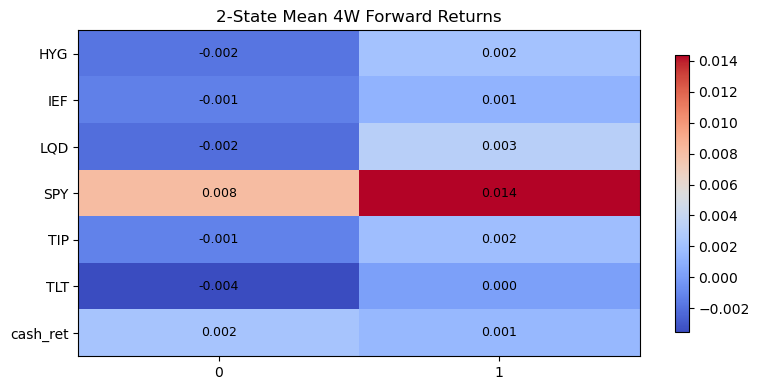

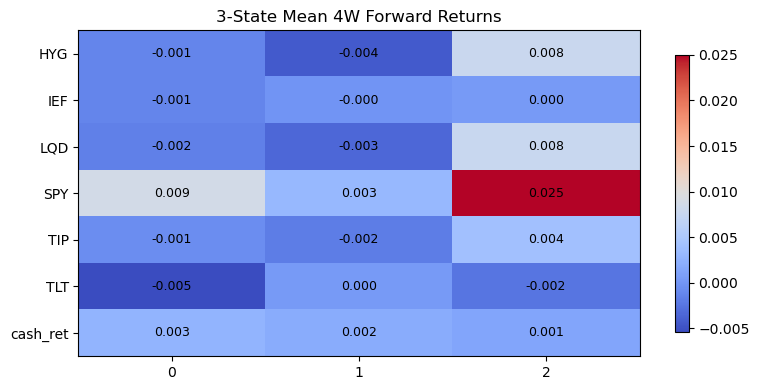

In [50]:
data_helpers.plot_mean_table(data_helpers.regime_mean_table(results_2s, 4), title="2-State Mean 4W Forward Returns")
data_helpers.plot_mean_table(data_helpers.regime_mean_table(results_3s, 4), title="3-State Mean 4W Forward Returns")

## 2.7 Model Enriching

In [51]:
extra_series_map={
    "oil_wti": "DCOILWTICO",   
    "usd_broad": "DTWEXBGS",          
    "infl_5y5y": "T5YIFR",     
    "unrate": "UNRATE",         
    "sahm_realtime": "SAHMREALTIME"
}

def load_extra_series(vintage_date, api_key,
                      observation_start=None, observation_end=None,
                      series_map=None):
    series_map = extra_series_map if series_map is None else series_map

    out = {}
    for name, sid in series_map.items():
        out[name] = get_alfred_series_asof(
            series_id=sid,
            vintage_date=vintage_date,
            api_key=api_key,
            observation_start=observation_start,
            observation_end=observation_end,
        )

    df = pd.concat(out, axis=1).sort_index()
    return df

extra_series_df = load_extra_series(
    vintage_date="2026-03-07",
    api_key=os.environ['FRED_API_KEY'],
    observation_start="2014-01-01",
)

In [52]:
extra_series_df.head()

,oil_wti,usd_broad,infl_5y5y,unrate,sahm_realtime
date,,,,,
2014-01-01,NaN,NaN,NaN,6.6,-0.2
2014-01-02,95.14,93.8192,2.81,NaN,NaN
2014-01-03,93.66,93.8530,2.83,NaN,NaN
2014-01-06,93.12,93.9109,2.77,NaN,NaN
2014-01-07,93.31,94.0398,2.69,NaN,NaN


In [53]:
def extract_ust_from_s_weekly(s_weekly):
    df = s_weekly.copy()
    df.index = pd.to_datetime(df.index)

    c_2y = 'ust_2y'
    c_10y = 'ust_10y'

    out = df[[c_2y, c_10y]].copy()
    out = out.rename(columns={c_2y: "ust_2y", c_10y: "ust_10y"})
    return out.sort_index()

ust_weekly = extract_ust_from_s_weekly(s_weekly)

In [54]:
infl_nowcast_daily = pd.read_parquet(Path('data')/'infl_nowcast.parquet')

In [55]:
infl_weekly = data_helpers.to_weekly_level_panel(infl_nowcast_daily,research_index=X_core.index,freq="W-FRI",ffill=True)
extra_weekly = data_helpers.to_weekly_level_panel(extra_series_df,research_index=X_core.index,freq="W-FRI", ffill=True)
ust_weekly = data_helpers.to_weekly_level_panel(ust_weekly,research_index=X_core.index,freq="W-FRI",ffill=True)

In [56]:
X_complete_weekly_raw = (
    X_core.join(extra_weekly, how="left")
            .join(ust_weekly, how="left")
            .join(infl_weekly, how="left")
            .sort_index()
)

In [57]:
X_complete_weekly, common_start = data_helpers.trim_to_common_sample(X_complete_weekly_raw)

In [59]:
def make_enriched_engineered_features(X):
    X = X.copy().sort_index()
    out = pd.DataFrame(index=X.index)

    # Growth
    if "GDPNow" in X.columns:
        out["growth_gdpnow_lvl"] = X["GDPNow"]
        out["growth_gdpnow_d4"] = X["GDPNow"].diff(4)

    if "ICSA" in X.columns:
        icsa_log = np.log(X["ICSA"])
        out["growth_claims_lvl"] = -icsa_log
        out["growth_claims_d4"] = -icsa_log.diff(4)

    if "unrate" in X.columns:
        out["growth_unrate_lvl"] = -X["unrate"]
        out["growth_unrate_d8"] = -X["unrate"].diff(8)

    if "sahm_realtime" in X.columns:
        out["growth_sahm_lvl"] = -X["sahm_realtime"]
        out["growth_sahm_d4"] = -X["sahm_realtime"].diff(4)

    # Rates / inflation pressure
    if "T10YIE" in X.columns:
        out["rates_breakeven10_lvl"] = X["T10YIE"]
        out["rates_breakeven10_d4"] = X["T10YIE"].diff(4)

    if "infl_5y5y" in X.columns:
        out["rates_5y5y_lvl"] = X["infl_5y5y"]
        out["rates_5y5y_d4"] = X["infl_5y5y"].diff(4)

    if "DFII10" in X.columns:
        out["rates_real10_lvl"] = X["DFII10"]
        out["rates_real10_d4"] = X["DFII10"].diff(4)

    if "ust_2y" in X.columns:
        out["rates_2y_lvl"] = X["ust_2y"]
        out["rates_2y_d4"] = X["ust_2y"].diff(4)

    if "ust_10y" in X.columns:
        out["rates_10y_lvl"] = X["ust_10y"]
        out["rates_10y_d4"] = X["ust_10y"].diff(4)

    if "ust_2y" in X.columns and "ust_10y" in X.columns:
        curve_10y2y = X["ust_10y"] - X["ust_2y"]
        out["rates_curve_inv_10y2y_lvl"] = -curve_10y2y
        out["rates_curve_inv_10y2y_d4"] = -curve_10y2y.diff(4)

    if "T10Y3M" in X.columns:
        out["rates_curve_inv_10y3m_lvl"] = -X["T10Y3M"]
        out["rates_curve_inv_10y3m_d4"] = -X["T10Y3M"].diff(4)

    if "core_cpi_inflation_mom" in X.columns:
        out["rates_core_cpi_mom_lvl"] = X["core_cpi_inflation_mom"]
        out["rates_core_cpi_mom_d4"] = X["core_cpi_inflation_mom"].diff(4)

    if "core_pce_inflation_mom" in X.columns:
        out["rates_core_pce_mom_lvl"] = X["core_pce_inflation_mom"]
        out["rates_core_pce_mom_d4"] = X["core_pce_inflation_mom"].diff(4)

    # Stress / liquidity
    if "ANFCI" in X.columns:
        out["stress_anfci_lvl"] = X["ANFCI"]
        out["stress_anfci_d4"] = X["ANFCI"].diff(4)
    elif "NFCI" in X.columns:
        out["stress_nfci_lvl"] = X["NFCI"]
        out["stress_nfci_d4"] = X["NFCI"].diff(4)

    if "HY_OAS" in X.columns:
        hy_log = np.log(X["HY_OAS"])
        out["stress_hy_oas_lvl"] = hy_log
        out["stress_hy_oas_d4"] = hy_log.diff(4)

    if "VIX" in X.columns:
        vix_log = np.log(X["VIX"])
        out["stress_vix_lvl"] = vix_log
        out["stress_vix_d4"] = vix_log.diff(4)

    if "EPU" in X.columns:
        epu_log = np.log(X["EPU"])
        out["stress_epu_lvl"] = epu_log
        out["stress_epu_d4"] = epu_log.diff(4)

    if "usd_broad" in X.columns:
        usd_log = np.log(X["usd_broad"])
        out["stress_usd_lvl"] = usd_log
        out["stress_usd_d4"] = usd_log.diff(4)

    # Inflation / commodity shock
    if "oil_wti" in X.columns:
        oil_log = np.log(X["oil_wti"].replace(0, np.nan))
        out["inflshock_oil_lvl"] = oil_log
        out["inflshock_oil_d4"] = oil_log.diff(4)

    if "cpi_inflation_mom" in X.columns:
        out["inflshock_cpi_mom_lvl"] = X["cpi_inflation_mom"]
        out["inflshock_cpi_mom_d4"] = X["cpi_inflation_mom"].diff(4)

    if "pce_inflation_mom" in X.columns:
        out["inflshock_pce_mom_lvl"] = X["pce_inflation_mom"]
        out["inflshock_pce_mom_d4"] = X["pce_inflation_mom"].diff(4)

    return out

In [60]:
def build_enriched_bucket_scores(Z):
    """
    4-bucket version:
    - growth
    - rates_pressure
    - stress
    - inflation_shock
    """
    B = pd.DataFrame(index=Z.index)

    growth_cols = [c for c in Z.columns if c.startswith("growth_")]
    rates_cols = [c for c in Z.columns if c.startswith("rates_")]
    stress_cols = [c for c in Z.columns if c.startswith("stress_")]
    inflshock_cols = [c for c in Z.columns if c.startswith("inflshock_")]

    if growth_cols:
        B["growth"] = Z[growth_cols].mean(axis=1)
        B["growth_d4"] = B["growth"].diff(4)

    if rates_cols:
        B["rates_pressure"] = Z[rates_cols].mean(axis=1)
        B["rates_pressure_d4"] = B["rates_pressure"].diff(4)

    if stress_cols:
        B["stress"] = Z[stress_cols].mean(axis=1)
        B["stress_d4"] = B["stress"].diff(4)

    if inflshock_cols:
        B["inflation_shock"] = Z[inflshock_cols].mean(axis=1)
        B["inflation_shock_d4"] = B["inflation_shock"].diff(4)

    return B

In [61]:
X_enriched_feat_raw = make_enriched_engineered_features(X_complete_weekly)
X_enriched_feat_z = data_helpers.rolling_zscore(X_enriched_feat_raw, window=104, min_periods=52, clip=4.0)
X_enriched_bucket = build_enriched_bucket_scores(X_enriched_feat_z)

In [94]:
X_model_enriched_3 = X_enriched_bucket[["growth","rates_pressure","stress"]].dropna().copy()
X_model_4 = X_enriched_bucket[["growth", "rates_pressure", "stress","inflation_shock"]].dropna().copy()

In [ ]:
enriched3 = data_helpers.run_regime_workflow(
    X_model=X_model_enriched_3,
    k=3,
    refit_every=4,          # slower refit
    smooth_window=3,        # smoothed probabilities
    min_train=104,          # 2 years weekly
    covariance_type="diag",
    seeds=range(20),
    n_iter=1500,
    tol=1e-4,
)

display(enriched3["full_hmm_results"])
display(enriched3["transition_matrix"])
display(enriched3["implied_duration"])
display(enriched3["full_hmm"]["summary"])
display(enriched3["oos_means"])
display(enriched3["oos_summary"])

Model is not converging.  Current: -56.56231040430123 is not greater than -56.56221867734938. Delta is -9.17269518510011e-05
Model is not converging.  Current: -71.20398393907122 is not greater than -71.20396572275226. Delta is -1.821631896348208e-05
Model is not converging.  Current: -74.16332362230301 is not greater than -74.16331275506529. Delta is -1.0867237719480727e-05
Model is not converging.  Current: -74.2603854059055 is not greater than -74.26037500171704. Delta is -1.0404188458323915e-05
Model is not converging.  Current: -75.17526301339616 is not greater than -75.1752348805494. Delta is -2.8132846765061004e-05
Model is not converging.  Current: -74.69394996060697 is not greater than -74.69366576286022. Delta is -0.00028419774675114695
Model is not converging.  Current: -77.14589601892669 is not greater than -77.14585534447399. Delta is -4.067445270550252e-05
Model is not converging.  Current: -81.48233092657775 is not greater than -81.48232652381385. Delta is -4.40276389213

,model,k,best_seed,loglik,aic,bic
0,HMM,3,8,-865.379249,1782.758498,1893.106837


,state_0,state_1,state_2
state_0,0.969079,1.148746e-02,0.019433
state_1,0.006159,9.828132e-01,0.011028
state_2,0.127896,6.523099e-26,0.872104


state_0    32.340970
state_1    58.184287
state_2     7.818837
Name: implied_duration, dtype: float64

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,-0.021878,-0.143838,-0.215076,0.425556,0.295101,0.389356,274,0.532039,30.444444,27.0,63,9
1,0.352498,0.620210,0.009689,0.350384,0.301102,0.567312,186,0.361165,62.000000,63.0,100,3
2,-1.147910,-0.754195,0.952287,1.125482,0.455164,0.925128,55,0.106796,7.857143,6.0,19,7


,growth,rates_pressure,stress
state,,,
0,0.100268,0.260685,0.044089
1,0.004308,0.035982,-0.159861
2,-0.713491,-0.556863,0.410598


,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,171,0.415049,17.100000,8.0,71,10
1,154,0.373786,11.846154,4.0,59,13
2,87,0.211165,12.428571,9.0,43,7


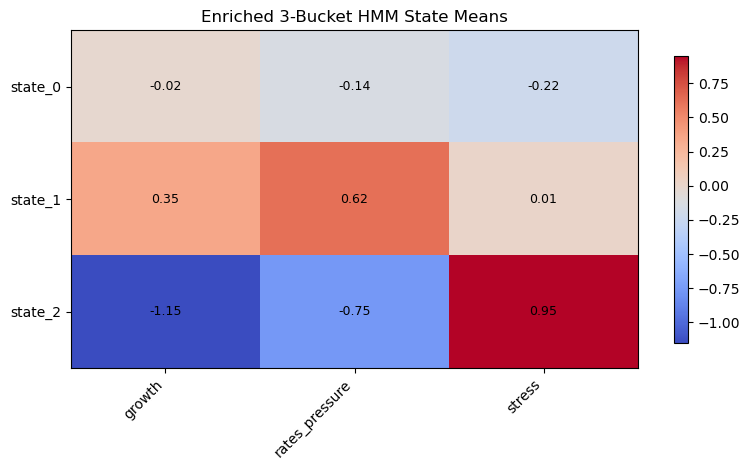

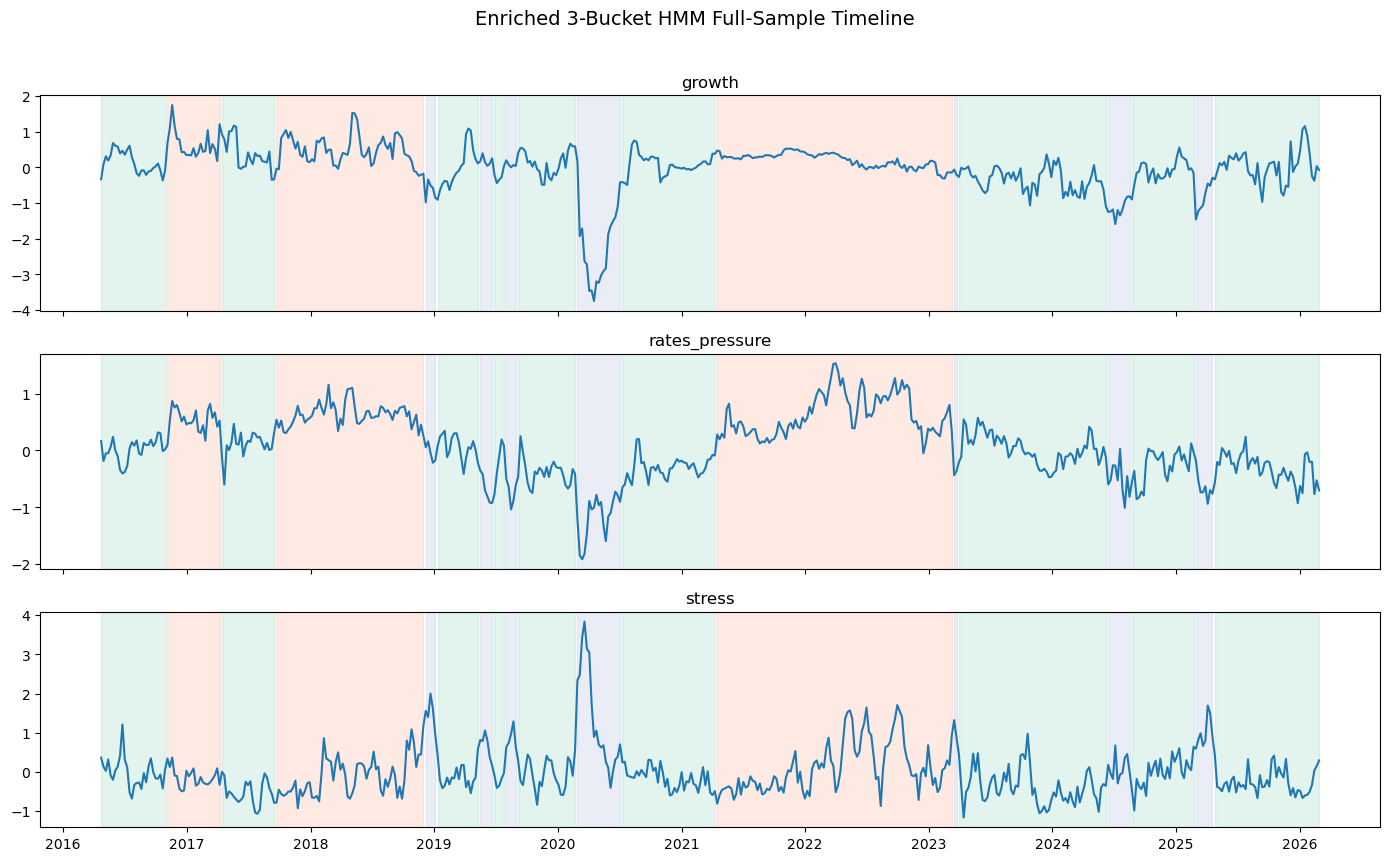

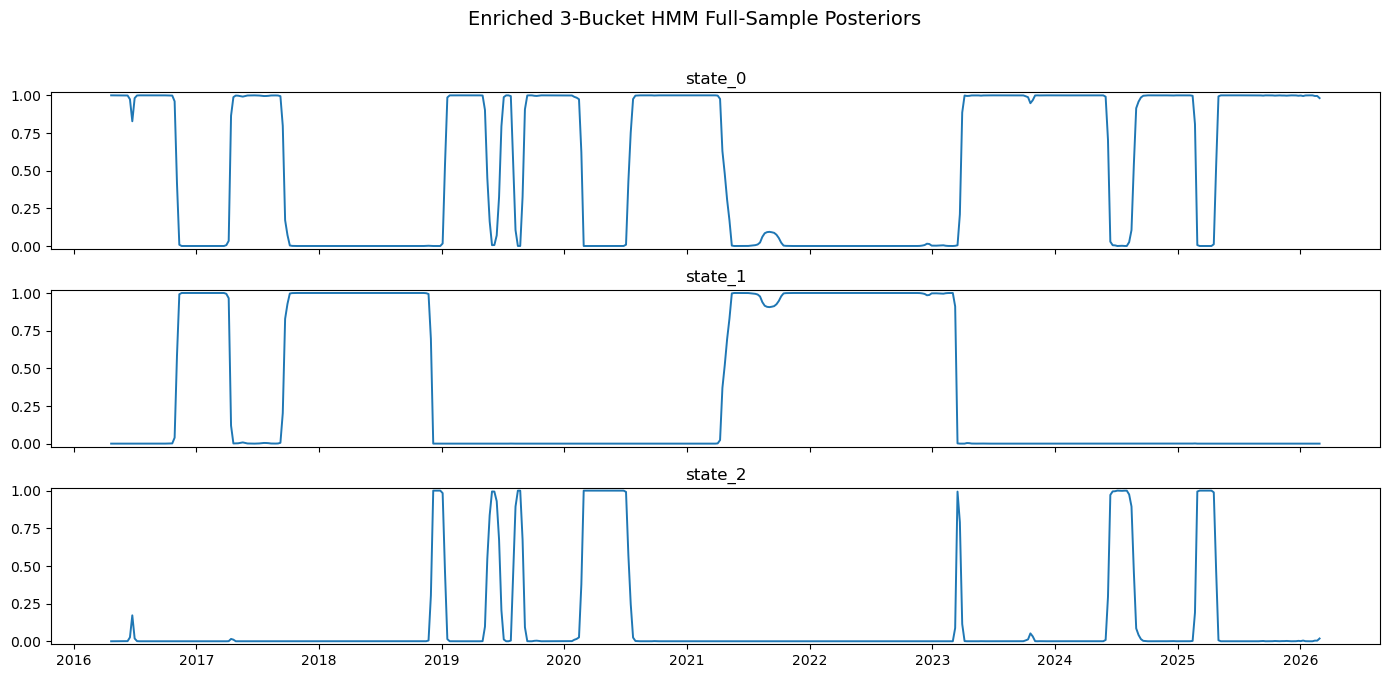

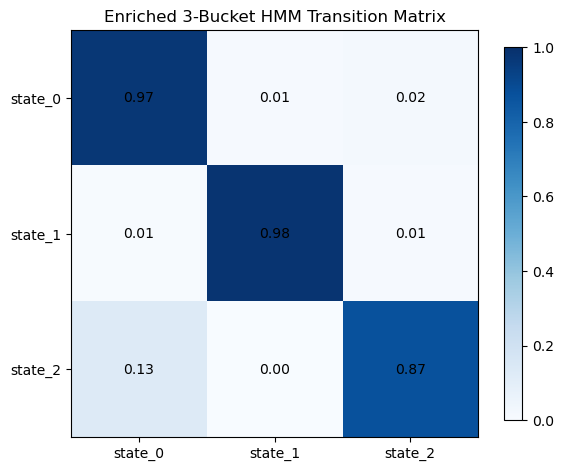

In [97]:
# Full-sample diagnostics: enriched 3-bucket
data_helpers.plot_state_means(enriched3["full_hmm"]["summary"], title="Enriched 3-Bucket HMM State Means")
data_helpers.plot_regime_timeline(
    enriched3["X_model"],
    enriched3["full_hmm"]["labels"],
    title="Enriched 3-Bucket HMM Full-Sample Timeline"
)
data_helpers.plot_hmm_posteriors(
    enriched3["full_hmm"]["probs"],
    title="Enriched 3-Bucket HMM Full-Sample Posteriors"
)
data_helpers.plot_transition_matrix(
    enriched3["transition_matrix"],
    title="Enriched 3-Bucket HMM Transition Matrix"
)

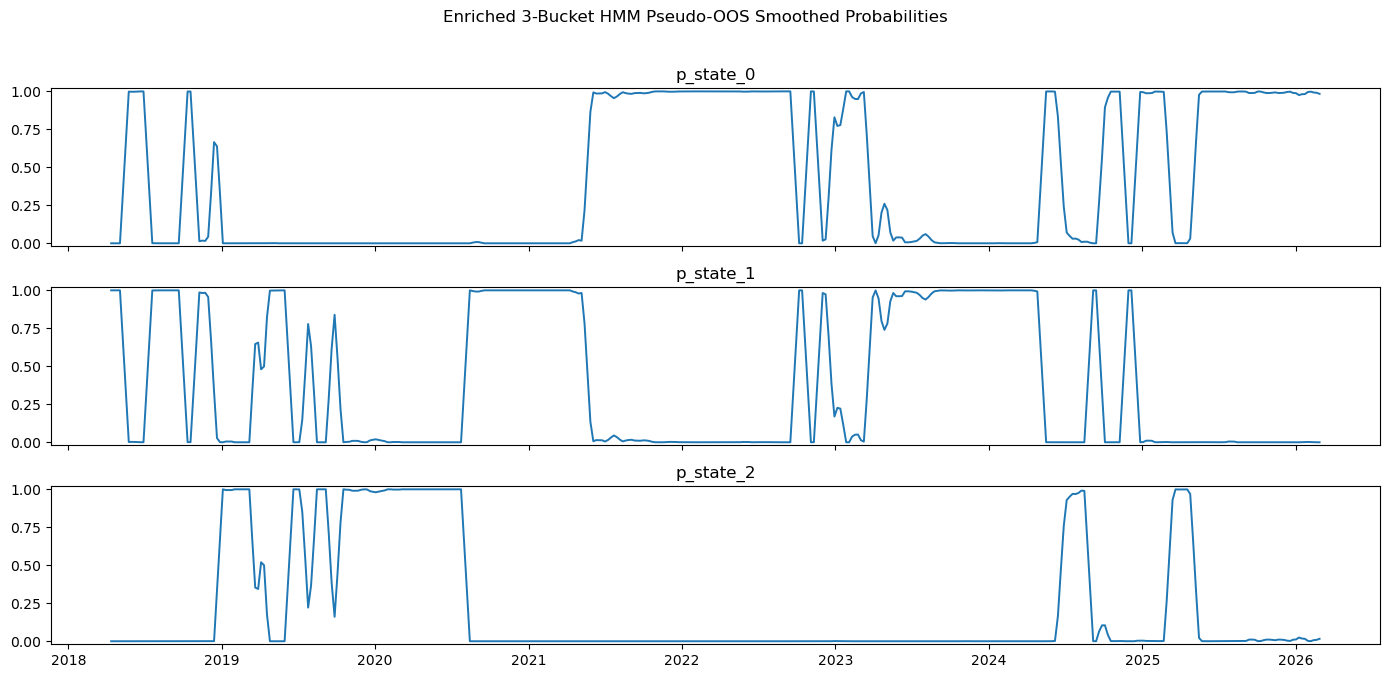

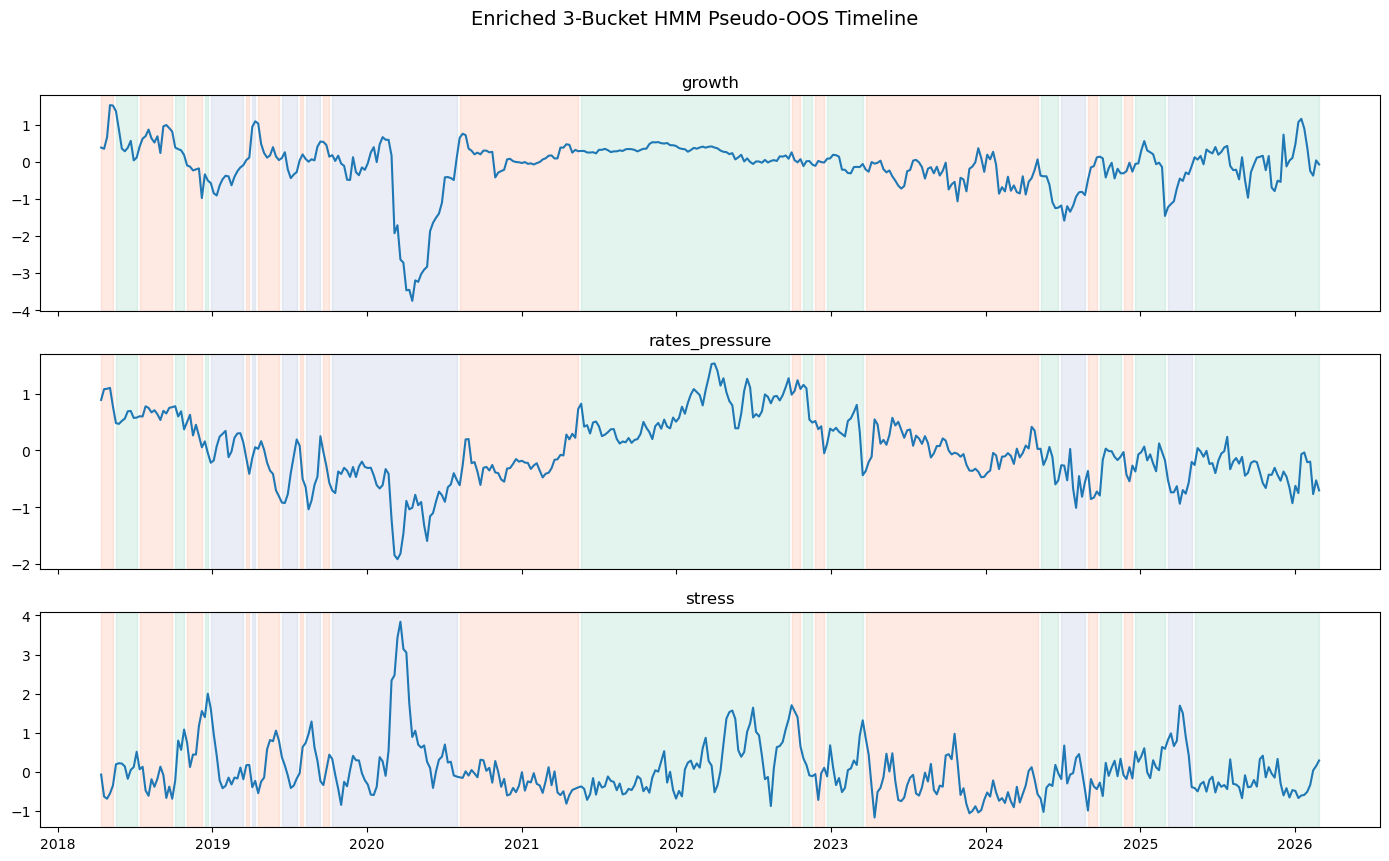

In [98]:
# Pseudo-OOS diagnostics: enriched 3-bucket
data_helpers.plot_oos_state_probs(
    enriched3["probs_oos_s"],
    title="Enriched 3-Bucket HMM Pseudo-OOS Smoothed Probabilities"
)
data_helpers.plot_oos_state_timeline(
    enriched3["X_model"],
    enriched3["probs_oos_s"],
    title="Enriched 3-Bucket HMM Pseudo-OOS Timeline"
)

Enriched 3-bucket: 4-week mean forward returns


state,0,1,2
asset,,,
HYG,-0.003598,0.001338,0.003287
IEF,-0.001436,-0.003067,0.006551
LQD,-0.002855,-0.001563,0.008081
SPY,0.004263,0.013710,0.017248
TIP,-0.002232,-0.000870,0.005717
TLT,-0.002243,-0.009346,0.010822
cash_ret,0.001975,0.002247,0.001524


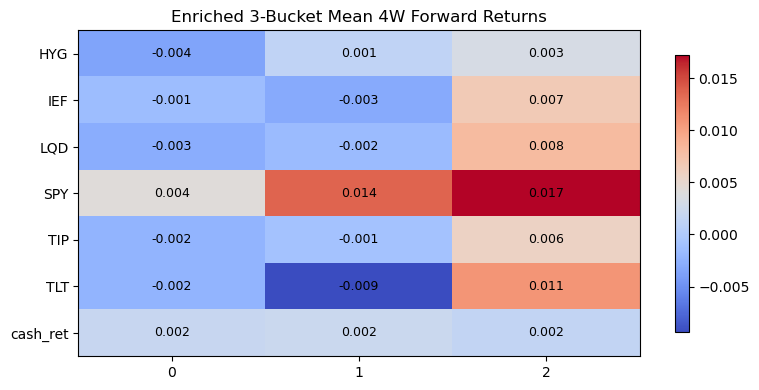

In [99]:
asset_ret_enriched3 = align_asset_returns(asset_returns, enriched3["probs_oos_s"].index)

results_enriched3 = data_helpers.regime_forward_return_stats(
    state_series=enriched3["probs_oos_s"]["state"],
    asset_returns=asset_ret_enriched3,
    horizons=(1, 4, 12),
)

print("Enriched 3-bucket: 4-week mean forward returns")
mean_4w_enriched3 = data_helpers.regime_mean_table(results_enriched3, horizon=4)
display(mean_4w_enriched3)
data_helpers.plot_mean_table(mean_4w_enriched3, title="Enriched 3-Bucket Mean 4W Forward Returns")

In [100]:
asset_ret_enriched3

,HYG,IEF,LQD,SPY,TIP,TLT,cash_ret
2018-04-13,0.011962,-0.003304,-0.000940,0.020907,0.002126,-0.001652,0.000336
2018-04-20,-0.004636,-0.009846,-0.012739,0.005506,-0.006454,-0.020182,0.000336
2018-04-27,-0.001514,0.000197,-0.001299,-0.000188,0.001246,0.003630,0.000336
2018-05-04,-0.003965,0.000492,-0.005636,-0.002026,-0.003733,0.000841,0.000354
2018-05-11,0.003629,-0.002263,0.005145,0.025675,-0.000268,0.002017,0.000354
...,...,...,...,...,...,...,...
2026-01-30,-0.000246,-0.000104,-0.002436,0.003975,0.002268,-0.009098,0.000675
2026-02-06,-0.003821,0.001355,-0.000090,-0.001951,0.001720,0.004706,0.000680
2026-02-13,0.000495,0.011866,0.009316,-0.012844,0.006506,0.024903,0.000680
2026-02-20,0.001855,-0.001234,0.000000,0.011265,-0.001795,-0.003455,0.000680


In [101]:
asset_ret_enriched3["TIP_minus_TLT"] = asset_ret_enriched3["TIP"] - asset_ret_enriched3["TLT"]
asset_ret_enriched3["SPY_minus_cash"] = asset_ret_enriched3["SPY"] - asset_ret_enriched3["cash_ret"]
asset_ret_enriched3["LQD_minus_IEF"] = asset_ret_enriched3["LQD"] - asset_ret_enriched3["IEF"]
asset_ret_enriched3["HYG_minus_IEF"] = asset_ret_enriched3["HYG"] - asset_ret_enriched3["IEF"]

state,0,1,2
asset,,,
TIP_minus_TLT,-0.000087,0.008657,-0.005566
SPY_minus_cash,0.002279,0.011446,0.015712
LQD_minus_IEF,-0.001457,0.001486,0.001622
HYG_minus_IEF,-0.002178,0.004419,-0.003344


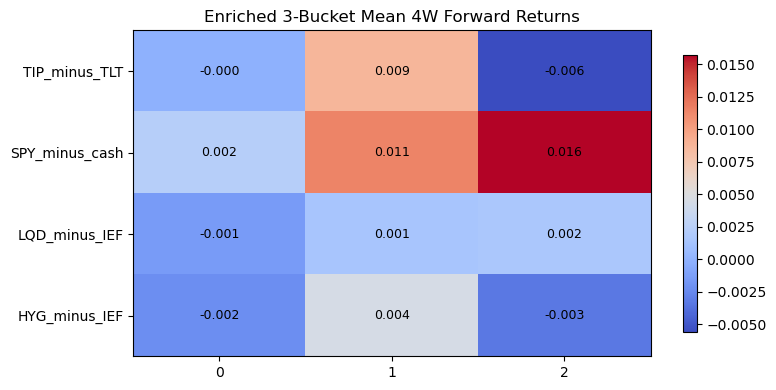

In [102]:
spread_results_enriched_3s = data_helpers.regime_forward_return_stats(
    state_series=enriched3["probs_oos_s"]["state"],
    asset_returns=asset_ret_enriched3[["TIP_minus_TLT", "SPY_minus_cash", "LQD_minus_IEF", "HYG_minus_IEF"]],
    horizons=(1, 4, 12),
)
mean_4w_spread_enriched3 = data_helpers.regime_mean_table(spread_results_enriched_3s, horizon=4)
display(mean_4w_spread_enriched3)
data_helpers.plot_mean_table(mean_4w_spread_enriched3, title="Enriched 3-Bucket Mean 4W Forward Returns")

state,0,1,2
asset,,,
TIP_minus_TLT,0.000047,0.001680,-0.000572
SPY_minus_cash,0.000062,0.003506,0.004099
LQD_minus_IEF,-0.000360,0.000279,0.000684
HYG_minus_IEF,-0.000644,0.000944,-0.000040


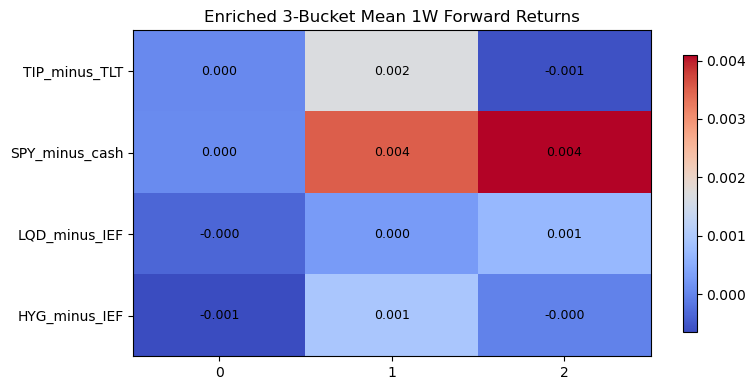

In [103]:
mean_1w_spread_enriched3 = data_helpers.regime_mean_table(spread_results_enriched_3s, horizon=1)
display(mean_1w_spread_enriched3)
data_helpers.plot_mean_table(mean_1w_spread_enriched3, title="Enriched 3-Bucket Mean 1W Forward Returns")

state,0,1,2
asset,,,
TIP_minus_TLT,0.004473,0.002474,0.014728
SPY_minus_cash,0.018254,0.014112,0.053327
LQD_minus_IEF,0.000295,-0.002896,0.008633
HYG_minus_IEF,-0.002244,-0.002977,0.010602


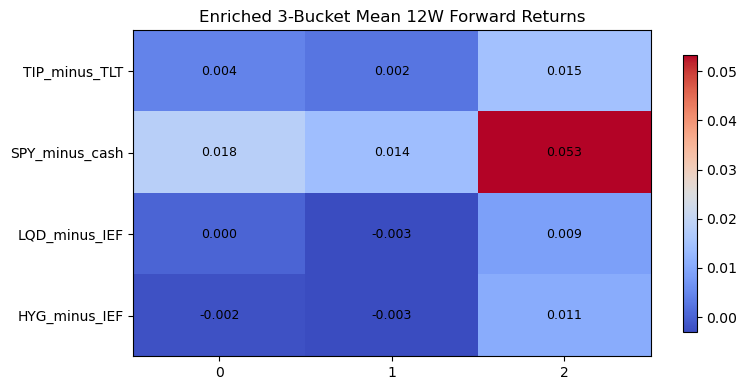

In [73]:
mean_12w_spread_enriched3 = data_helpers.regime_mean_table(spread_results_enriched_3s, horizon=12)
display(mean_12w_spread_enriched3)
data_helpers.plot_mean_table(mean_12w_spread_enriched3, title="Enriched 3-Bucket Mean 12W Forward Returns")

### Risk Metrics

In [104]:
state_series = enriched3["probs_oos_s"]["state"]
spread_ret_df = asset_ret_enriched3[["TIP_minus_TLT", "SPY_minus_cash", "LQD_minus_IEF", "HYG_minus_IEF"]]

mean_tests, diff_tests, boot_tests = data_helpers.run_caution_checks_all_spreads(
    state_series=state_series,
    spread_ret_df=spread_ret_df,
    horizons=(1, 4, 12),
)

display(diff_tests.sort_values(["asset", "horizon", "state_a", "state_b"]))
display(boot_tests.sort_values(["asset", "horizon", "state_a", "state_b"]))

,state_a,state_b,n_obs,mean_a,mean_b,diff_b_minus_a,se_hac,t_hac,pvalue_hac,asset,horizon
27,0.0,1.0,325.0,-0.000644,0.000944,0.001588,0.001042,1.524189,0.127461,HYG_minus_IEF,1
28,0.0,2.0,258.0,-0.000644,-0.000040,0.000605,0.002699,0.224000,0.822757,HYG_minus_IEF,1
29,1.0,2.0,241.0,0.000944,-0.000040,-0.000983,0.002662,-0.369417,0.711817,HYG_minus_IEF,1
30,0.0,1.0,322.0,-0.002178,0.004419,0.006597,0.002819,2.340157,0.019276,HYG_minus_IEF,4
31,0.0,2.0,255.0,-0.002178,-0.003344,-0.001166,0.008088,-0.144168,0.885368,HYG_minus_IEF,4
32,1.0,2.0,241.0,0.004419,-0.003344,-0.007763,0.008176,-0.949587,0.342322,HYG_minus_IEF,4
33,0.0,1.0,314.0,-0.005003,0.011736,0.016738,0.006600,2.535988,0.011213,HYG_minus_IEF,12
34,0.0,2.0,247.0,-0.005003,-0.011325,-0.006322,0.020064,-0.315086,0.752696,HYG_minus_IEF,12
35,1.0,2.0,241.0,0.011736,-0.011325,-0.023060,0.020381,-1.131443,0.257869,HYG_minus_IEF,12
18,0.0,1.0,325.0,-0.000360,0.000279,0.000639,0.000587,1.087995,0.276597,LQD_minus_IEF,1


,state_a,state_b,obs_diff,boot_mean,boot_std,ci_5,ci_50,ci_95,asset,horizon
27,0.0,1.0,0.001588,0.001448,0.000999,-0.000198,0.001455,0.003097,HYG_minus_IEF,1
28,0.0,2.0,0.000605,0.000632,0.002565,-0.003777,0.000809,0.004558,HYG_minus_IEF,1
29,1.0,2.0,-0.000983,-0.000816,0.002640,-0.005226,-0.000602,0.003093,HYG_minus_IEF,1
30,0.0,1.0,0.006597,0.006412,0.003062,0.001265,0.006394,0.011282,HYG_minus_IEF,4
31,0.0,2.0,-0.001166,-0.001204,0.008586,-0.016394,-0.000435,0.011548,HYG_minus_IEF,4
32,1.0,2.0,-0.007763,-0.007616,0.008818,-0.023523,-0.006810,0.005275,HYG_minus_IEF,4
33,0.0,1.0,0.016738,0.018177,0.007305,0.005737,0.018419,0.029928,HYG_minus_IEF,12
34,0.0,2.0,-0.006322,-0.003434,0.018046,-0.033862,-0.003150,0.024084,HYG_minus_IEF,12
35,1.0,2.0,-0.023060,-0.021611,0.018512,-0.054406,-0.020842,0.006071,HYG_minus_IEF,12
18,0.0,1.0,0.000639,0.000638,0.000573,-0.000282,0.000623,0.001610,LQD_minus_IEF,1


In [105]:
cond_risk_stats = data_helpers.state_conditional_risk_stats(
    state_series=state_series,
    ret_df=spread_ret_df,
    ann_factor=52
)

display(cond_risk_stats)

timed_stats = data_helpers.timed_state_strategy_stats(
    state_series=state_series,
    ret_df=spread_ret_df,
    lag=1,
    ann_factor=52
)

display(timed_stats)

,asset,state,n_obs,mean_w,vol_w,hit_rate,ann_mean,ann_vol,sharpe,sortino,max_drawdown
0,HYG_minus_IEF,0,171,-0.000644,0.010729,0.520468,-0.033501,0.077370,-0.432999,-0.539681,-0.152893
1,HYG_minus_IEF,1,154,0.000944,0.009383,0.571429,0.049078,0.067663,0.725335,1.085536,-0.163287
2,HYG_minus_IEF,2,87,-0.000040,0.028565,0.597701,-0.002059,0.205983,-0.009998,-0.010770,-0.267427
3,LQD_minus_IEF,0,171,-0.000360,0.005749,0.444444,-0.018726,0.041454,-0.451720,-0.722905,-0.088575
4,LQD_minus_IEF,1,154,0.000279,0.005269,0.545455,0.014501,0.037995,0.381650,0.548762,-0.067303
5,LQD_minus_IEF,2,87,0.000684,0.025561,0.586207,0.035579,0.184322,0.193025,0.192710,-0.228527
6,SPY_minus_cash,0,171,0.000062,0.023013,0.502924,0.003235,0.165946,0.019492,0.028684,-0.281539
7,SPY_minus_cash,1,154,0.003506,0.019969,0.590909,0.182323,0.144000,1.266131,2.005630,-0.112879
8,SPY_minus_cash,2,87,0.004099,0.036128,0.632184,0.213148,0.260523,0.818155,0.830217,-0.322819
9,TIP_minus_TLT,0,171,0.000047,0.015093,0.491228,0.002467,0.108840,0.022663,0.034980,-0.146665


,asset,state,exposure,mean_w,vol_w,hit_rate,ann_mean,ann_vol,sharpe,sortino,max_drawdown
0,HYG_minus_IEF,0,0.412621,-0.000310,0.006865,0.213592,-0.016136,0.049502,-0.325959,-0.260046,-0.164835
1,HYG_minus_IEF,1,0.373786,0.000447,0.005796,0.220874,0.023225,0.041798,0.555643,0.508493,-0.126362
2,HYG_minus_IEF,2,0.211165,-0.000096,0.013040,0.118932,-0.005010,0.094031,-0.053283,-0.026958,-0.267427
3,LQD_minus_IEF,0,0.412621,-0.000170,0.003763,0.182039,-0.008842,0.027134,-0.325871,-0.329329,-0.101640
4,LQD_minus_IEF,1,0.373786,0.000078,0.003116,0.199029,0.004037,0.022472,0.179644,0.162711,-0.067802
5,LQD_minus_IEF,2,0.211165,0.000186,0.011702,0.128641,0.009668,0.084387,0.114569,0.051028,-0.228527
6,SPY_minus_cash,0,0.412621,0.000148,0.014925,0.216019,0.007706,0.107624,0.071598,0.067093,-0.280655
7,SPY_minus_cash,1,0.373786,0.001152,0.012254,0.213592,0.059909,0.088364,0.677975,0.672588,-0.112879
8,SPY_minus_cash,2,0.211165,0.000852,0.016515,0.131068,0.044291,0.119094,0.371901,0.174150,-0.322819
9,TIP_minus_TLT,0,0.412621,0.000020,0.009473,0.201456,0.001048,0.068310,0.015346,0.014848,-0.142259


In [106]:
sharpe_table = data_helpers.pivot_metric(timed_stats, "sharpe")
vol_table = data_helpers.pivot_metric(timed_stats, "ann_vol")
mdd_table = data_helpers.pivot_metric(timed_stats, "max_drawdown")

display(sharpe_table)
display(vol_table)
display(mdd_table)

state,0,1,2
asset,,,
HYG_minus_IEF,-0.325959,0.555643,-0.053283
LQD_minus_IEF,-0.325871,0.179644,0.114569
SPY_minus_cash,0.071598,0.677975,0.371901
TIP_minus_TLT,0.015346,0.593812,-0.262327


state,0,1,2
asset,,,
HYG_minus_IEF,0.049502,0.041798,0.094031
LQD_minus_IEF,0.027134,0.022472,0.084387
SPY_minus_cash,0.107624,0.088364,0.119094
TIP_minus_TLT,0.068310,0.069179,0.057957


state,0,1,2
asset,,,
HYG_minus_IEF,-0.164835,-0.126362,-0.267427
LQD_minus_IEF,-0.101640,-0.067802,-0.228527
SPY_minus_cash,-0.280655,-0.112879,-0.322819
TIP_minus_TLT,-0.142259,-0.161644,-0.192721


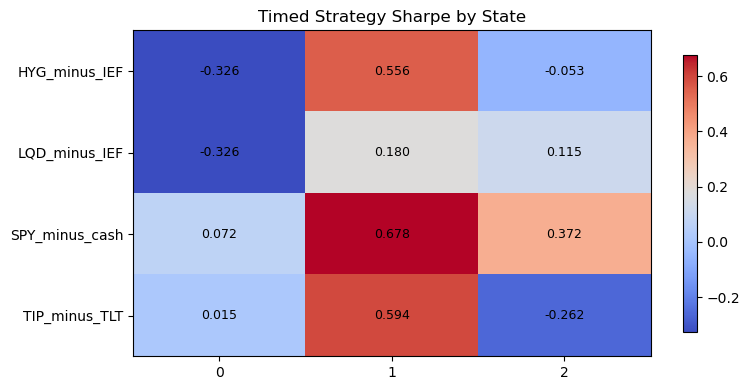

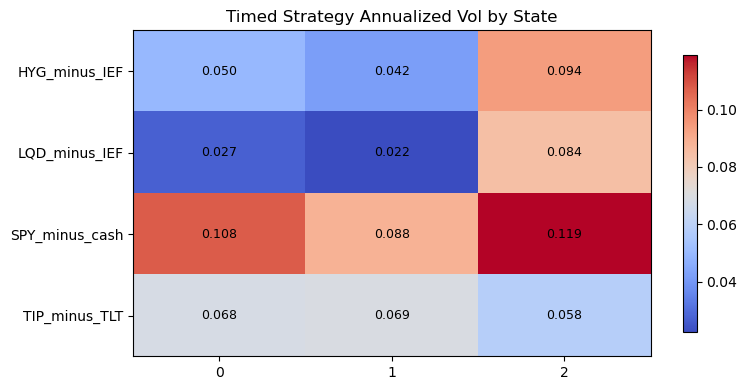

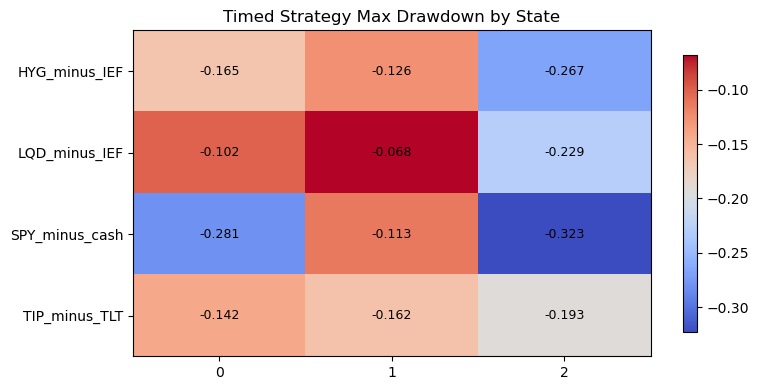

In [107]:
data_helpers.plot_metric_table(sharpe_table, "Timed Strategy Sharpe by State")
data_helpers.plot_metric_table(vol_table, "Timed Strategy Annualized Vol by State")
data_helpers.plot_metric_table(mdd_table, "Timed Strategy Max Drawdown by State")

In [108]:
# 1) HAC pairwise difference tests
display(diff_tests.query("horizon == 12").sort_values(["asset", "state_a", "state_b"]))

# 2) Block bootstrap confidence intervals
display(boot_tests.query("horizon == 12").sort_values(["asset", "state_a", "state_b"]))

# 3) Timed strategy risk metrics
display(timed_stats)

# 4) Pivot tables
display(sharpe_table)
display(vol_table)
display(mdd_table)

,state_a,state_b,n_obs,mean_a,mean_b,diff_b_minus_a,se_hac,t_hac,pvalue_hac,asset,horizon
33,0.0,1.0,314.0,-0.005003,0.011736,0.016738,0.006600,2.535988,0.011213,HYG_minus_IEF,12
34,0.0,2.0,247.0,-0.005003,-0.011325,-0.006322,0.020064,-0.315086,0.752696,HYG_minus_IEF,12
35,1.0,2.0,241.0,0.011736,-0.011325,-0.023060,0.020381,-1.131443,0.257869,HYG_minus_IEF,12
24,0.0,1.0,314.0,-0.006192,0.006930,0.013122,0.003633,3.611419,0.000305,LQD_minus_IEF,12
25,0.0,2.0,247.0,-0.006192,0.002869,0.009061,0.013083,0.692527,0.488606,LQD_minus_IEF,12
26,1.0,2.0,241.0,0.006930,0.002869,-0.004061,0.013065,-0.310853,0.755912,LQD_minus_IEF,12
15,0.0,1.0,314.0,-0.000008,0.039336,0.039344,0.014951,2.631466,0.008502,SPY_minus_cash,12
16,0.0,2.0,247.0,-0.000008,0.045562,0.045569,0.028415,1.603729,0.108774,SPY_minus_cash,12
17,1.0,2.0,241.0,0.039336,0.045562,0.006226,0.028444,0.218879,0.826744,SPY_minus_cash,12
6,0.0,1.0,314.0,0.008637,0.015843,0.007206,0.014162,0.508841,0.610863,TIP_minus_TLT,12


,state_a,state_b,obs_diff,boot_mean,boot_std,ci_5,ci_50,ci_95,asset,horizon
33,0.0,1.0,0.016738,0.018177,0.007305,0.005737,0.018419,0.029928,HYG_minus_IEF,12
34,0.0,2.0,-0.006322,-0.003434,0.018046,-0.033862,-0.003150,0.024084,HYG_minus_IEF,12
35,1.0,2.0,-0.023060,-0.021611,0.018512,-0.054406,-0.020842,0.006071,HYG_minus_IEF,12
24,0.0,1.0,0.013122,0.014440,0.003965,0.008024,0.014341,0.021144,LQD_minus_IEF,12
25,0.0,2.0,0.009061,0.010225,0.010764,-0.008587,0.010965,0.026528,LQD_minus_IEF,12
26,1.0,2.0,-0.004061,-0.004215,0.010507,-0.022495,-0.003846,0.011685,LQD_minus_IEF,12
15,0.0,1.0,0.039344,0.042405,0.016949,0.015370,0.042379,0.070793,SPY_minus_cash,12
16,0.0,2.0,0.045569,0.049843,0.026592,0.005395,0.050201,0.093063,SPY_minus_cash,12
17,1.0,2.0,0.006226,0.007438,0.024986,-0.033734,0.007489,0.047457,SPY_minus_cash,12
6,0.0,1.0,0.007206,0.006972,0.015073,-0.018134,0.007022,0.031059,TIP_minus_TLT,12


,asset,state,exposure,mean_w,vol_w,hit_rate,ann_mean,ann_vol,sharpe,sortino,max_drawdown
0,HYG_minus_IEF,0,0.412621,-0.000310,0.006865,0.213592,-0.016136,0.049502,-0.325959,-0.260046,-0.164835
1,HYG_minus_IEF,1,0.373786,0.000447,0.005796,0.220874,0.023225,0.041798,0.555643,0.508493,-0.126362
2,HYG_minus_IEF,2,0.211165,-0.000096,0.013040,0.118932,-0.005010,0.094031,-0.053283,-0.026958,-0.267427
3,LQD_minus_IEF,0,0.412621,-0.000170,0.003763,0.182039,-0.008842,0.027134,-0.325871,-0.329329,-0.101640
4,LQD_minus_IEF,1,0.373786,0.000078,0.003116,0.199029,0.004037,0.022472,0.179644,0.162711,-0.067802
5,LQD_minus_IEF,2,0.211165,0.000186,0.011702,0.128641,0.009668,0.084387,0.114569,0.051028,-0.228527
6,SPY_minus_cash,0,0.412621,0.000148,0.014925,0.216019,0.007706,0.107624,0.071598,0.067093,-0.280655
7,SPY_minus_cash,1,0.373786,0.001152,0.012254,0.213592,0.059909,0.088364,0.677975,0.672588,-0.112879
8,SPY_minus_cash,2,0.211165,0.000852,0.016515,0.131068,0.044291,0.119094,0.371901,0.174150,-0.322819
9,TIP_minus_TLT,0,0.412621,0.000020,0.009473,0.201456,0.001048,0.068310,0.015346,0.014848,-0.142259


state,0,1,2
asset,,,
HYG_minus_IEF,-0.325959,0.555643,-0.053283
LQD_minus_IEF,-0.325871,0.179644,0.114569
SPY_minus_cash,0.071598,0.677975,0.371901
TIP_minus_TLT,0.015346,0.593812,-0.262327


state,0,1,2
asset,,,
HYG_minus_IEF,0.049502,0.041798,0.094031
LQD_minus_IEF,0.027134,0.022472,0.084387
SPY_minus_cash,0.107624,0.088364,0.119094
TIP_minus_TLT,0.068310,0.069179,0.057957


state,0,1,2
asset,,,
HYG_minus_IEF,-0.164835,-0.126362,-0.267427
LQD_minus_IEF,-0.101640,-0.067802,-0.228527
SPY_minus_cash,-0.280655,-0.112879,-0.322819
TIP_minus_TLT,-0.142259,-0.161644,-0.192721


In [111]:
out_path = Path('data') / 'asset_returns.parquet'

In [113]:
out_prob_path = Path('data') / 'prob_oos.parquet' 

In [114]:
enriched3['probs_oos_s'].to_parquet(out_prob_path)

In [112]:
asset_ret_enriched3.to_parquet(out_path)

In [ ]:
results_4_3s = data_helpers.run_regime_workflow(
    X_model=X_model_4,
    k=3,
    refit_every=4,          # slower refit
    smooth_window=3,        # smoothed probabilities
    min_train=208,          # 2 years weekly
    covariance_type="diag",
    seeds=range(20),
    n_iter=1500,
    tol=1e-4,
)

display(results_4_3s["full_hmm_results"])
display(results_4_3s["transition_matrix"])
display(results_4_3s["implied_duration"])
display(results_4_3s["full_hmm"]["summary"])
display(results_4_3s["oos_means"])
display(results_4_3s["oos_summary"])

Model is not converging.  Current: -651.9079768344372 is not greater than -651.907968054933. Delta is -8.779504241829272e-06
Model is not converging.  Current: -797.2947861919689 is not greater than -797.2947850833623. Delta is -1.1086066251664306e-06
Model is not converging.  Current: -963.7132546723495 is not greater than -963.7132526657649. Delta is -2.0065846229044837e-06
Model is not converging.  Current: -1004.680437037841 is not greater than -1004.6803837914059. Delta is -5.3246435072651366e-05
Model is not converging.  Current: -1261.5544027790563 is not greater than -1261.5544001021096. Delta is -2.67694667854812e-06


,model,k,best_seed,loglik,aic,bic
0,HMM,3,0,-1335.71308,2735.42616,2871.239501


,state_0,state_1,state_2
state_0,0.968780,1.153169e-02,0.019689
state_1,0.005944,9.832465e-01,0.010810
state_2,0.122485,6.493931e-91,0.877515


state_0    32.030465
state_1    59.688883
state_2     8.164293
Name: implied_duration, dtype: float64

,growth_mean,rates_pressure_mean,stress_mean,inflation_shock_mean,growth_std,rates_pressure_std,stress_std,inflation_shock_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,,,
0,-0.021534,-0.133435,-0.223389,0.005222,0.422906,0.293950,0.389331,0.490571,272,0.528155,30.222222,27.0,63,9
1,0.351245,0.628691,0.011695,0.313890,0.355421,0.298820,0.562990,0.667071,182,0.353398,60.666667,63.0,96,3
2,-1.010404,-0.715748,0.883280,-0.694018,1.155287,0.458755,0.913563,0.946588,61,0.118447,8.714286,6.0,23,7


,growth,rates_pressure,stress,inflation_shock
state,,,,
0,-0.036946,0.123017,-0.137114,0.072954
1,0.074919,0.165111,-0.011929,0.063350
2,-1.115556,-0.681484,0.297408,-0.416552


,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,175,0.568182,25.000000,19.0,58,7
1,89,0.288961,14.833333,4.0,43,6
2,44,0.142857,11.000000,12.5,16,4


In [116]:
X_complete_weekly.columns

Index(['DFII10', 'ICSA', 'VIX', 'NFCI', 'ANFCI', 'T10YIE', 'T10Y3M', 'EPU',
       'HY_OAS', 'GDPNow', 'oil_wti', 'usd_broad', 'infl_5y5y', 'unrate',
       'sahm_realtime', 'ust_2y', 'ust_10y', 'cpi_inflation_mom',
       'core_cpi_inflation_mom', 'pce_inflation_mom',
       'core_pce_inflation_mom'],
      dtype='object')